# Submission Akhir: Menyelesaikan Permasalahan Institusi Pendidikan



*   Nama : Al Hadi Busra
*   ID Dicoding : alhadi78
*   Email Akun Dicoding : alhadibusra1002@gmail.com



## Library Preparation


In [7]:
# ============================================================
# INSTALL LIBRARIES
# ============================================================
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost lightgbm lazypredict joblib -q

In [8]:
# ============================================================
# BASIC LIBRARIES
# ============================================================
import pandas as pd
import numpy as np

# ============================================================
# VISUALIZATION
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# PREPROCESSING
# ============================================================
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# ============================================================
# METRICS / EVALUATION
# ============================================================
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

# ============================================================
# MACHINE LEARNING MODELS
# ============================================================
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    BaggingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Boosting Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ============================================================
# HANDLING IMBALANCED DATA
# ============================================================
from imblearn.over_sampling import SMOTE

# ============================================================
# MODEL SELECTION & TUNING
# ============================================================
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# ============================================================
# UTILITIES
# ============================================================
import joblib
import time
import warnings

warnings.filterwarnings('ignore')

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


In [9]:
# ============================================================
# CELL 3 — Load Dataset
# ============================================================
url = "https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/bce7a57a496d083716138922bc5839b5c30fa4ea/students_performance/data.csv"

df = pd.read_csv(url, sep=';')

print(f"✅ Dataset berhasil dimuat!")
print(f"Shape : {df.shape}")
print(f"Kolom : {df.columns.tolist()}")

✅ Dataset berhasil dimuat!
Shape : (4424, 37)
Kolom : ['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_rate', 'GDP',

In [10]:
# ============================================================
# CELL 4 — Cek Data Awal
# ============================================================
print("=== 5 Data Pertama ===")
display(df.head())

print("\n=== Info Dataset ===")
df.info()

=== 5 Data Pertama ===


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                    

## Data Understanding

### Tipe Data & Struktur Dataset

In [ ]:
# ============================================================
# Tipe Data & Struktur Dataset
# ============================================================
print("=== Tipe Data Setiap Kolom ===")
print(df.dtypes)

print("\n=== Jumlah Nilai Unik per Kolom ===")
print(df.nunique().sort_values())


=== Tipe Data Setiap Kolom ===
Marital_status                                    int64
Application_mode                                  int64
Application_order                                 int64
Course                                            int64
Daytime_evening_attendance                        int64
Previous_qualification                            int64
Previous_qualification_grade                    float64
Nacionality                                       int64
Mothers_qualification                             int64
Fathers_qualification                             int64
Mothers_occupation                                int64
Fathers_occupation                                int64
Admission_grade                                 float64
Displaced                                         int64
Educational_special_needs                         int64
Debtor                                            int64
Tuition_fees_up_to_date                           int64
Gender           

**Insight Tipe Data & Struktur Dataset**
*   **Tipe Data**: Dataset memiliki kombinasi kolom `int64`, `float64`, dan satu kolom `object` (`Status`). Kolom `Status` adalah target yang bersifat kategorikal.
*   **Keunikan Fitur**: Terdapat beberapa fitur dengan nilai unik yang sangat sedikit (misalnya, 2 nilai unik untuk `Daytime_evening_attendance`, `Displaced`, `Debtor`, dll.), menunjukkan bahwa mereka adalah fitur biner atau kategorikal dengan sedikit kategori. Sebaliknya, `Admission_grade` dan `Previous_qualification_grade` memiliki banyak nilai unik, mengindikasikan sifat kontinu.

### Missing Values

In [ ]:
# ============================================================
# Missing Values
# ============================================================
print("=== Pengecekan Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).sort_values('Missing Count', ascending=False)

display(missing_df[missing_df['Missing Count'] > 0])

if missing.sum() == 0:
    print("✅ Tidak ada missing values dalam dataset!")
else:
    print(f"⚠️ Total missing values: {missing.sum()}")

=== Pengecekan Missing Values ===


,Missing Count,Missing (%)


✅ Tidak ada missing values dalam dataset!


**Insight Missing Values**
*   **Tidak Ada Missing Values**: Dataset ini *bersih* dari missing values, yang merupakan kabar baik karena tidak memerlukan langkah imputasi.

### Distribusi Target (Status)

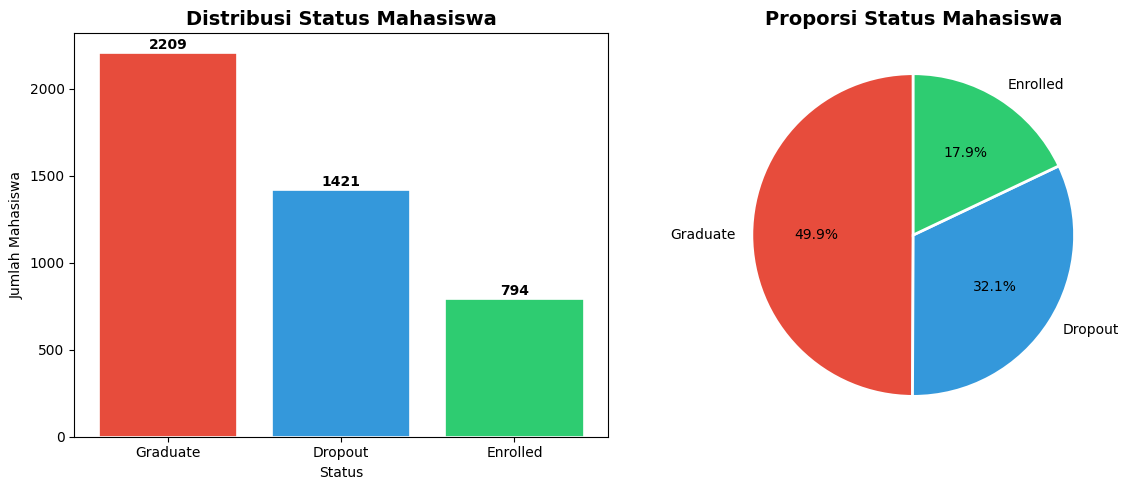

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [ ]:
# ============================================================
# Distribusi Target (Status)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
status_counts = df['Status'].value_counts()
colors = ['#e74c3c', '#3498db', '#2ecc71']

axes[0].bar(status_counts.index, status_counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribusi Status Mahasiswa', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Jumlah Mahasiswa')
for i, (val, count) in enumerate(zip(status_counts.index, status_counts.values)):
    axes[0].text(i, count + 20, str(count), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Status Mahasiswa', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_target.png', dpi=150, bbox_inches='tight')
plt.show()
print(status_counts)


**Insight Distribusi Target (Status)**
*   **Imbalanced Dataset**: Kolom target `Status` sangat tidak seimbang:
    *   `Graduate`: 2209 (49.9%)
    *   `Dropout`: 1421 (32.1%)
    *   `Enrolled`: 794 (17.9%)
*   **Implikasi**: Ketidakseimbangan ini penting untuk diperhatikan saat modeling, karena model mungkin cenderung bias ke kelas mayoritas (`Graduate`). Penanganan *class imbalance* akan diperlukan (misalnya, menggunakan SMOTE, *class weights*).

### Identifikasi Kolom Kategorikal vs Numerikal

In [ ]:
# ============================================================
# Identifikasi Kolom Kategorikal vs Numerikal
# ============================================================
# Kolom yang meskipun bertipe int, secara bisnis bersifat kategorikal
categorical_cols = [
    'Marital_status', 'Application_mode', 'Course',
    'Daytime_evening_attendance', 'Previous_qualification',
    'Nacionality', 'Mothers_qualification', 'Fathers_qualification',
    'Mothers_occupation', 'Fathers_occupation',
    'Displaced', 'Educational_special_needs', 'Debtor',
    'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'International'
]

numerical_cols = [col for col in df.columns if col not in categorical_cols + ['Status']]

print(f"Kolom Kategorikal ({len(categorical_cols)}):")
print(categorical_cols)

print(f"\nKolom Numerikal ({len(numerical_cols)}):")
print(numerical_cols)

Kolom Kategorikal (17):
['Marital_status', 'Application_mode', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'International']

Kolom Numerikal (19):
['Application_order', 'Previous_qualification_grade', 'Admission_grade', 'Age_at_enrollment', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_rate', 'GDP']


**Insight Identifikasi Kolom Kategorikal vs Numerikal**

*   **Definisi Jelas**: Ada 17 kolom yang diidentifikasi sebagai kategorikal (meskipun beberapa disimpan sebagai `int64`) dan 19 kolom sebagai numerikal. Pemisahan ini penting untuk langkah *preprocessing* selanjutnya.

### Statistik Deskriptif Kolom Numerikal

In [ ]:
# ============================================================
# Statistik Deskriptif Kolom Numerikal
# ============================================================
print("=== Statistik Deskriptif — Kolom Numerikal ===")
display(df[numerical_cols].describe().T.round(2))

=== Statistik Deskriptif — Kolom Numerikal ===


,count,mean,std,min,25%,50%,75%,max
Application_order,4424.0,1.73,1.31,0.00,1.00,1.00,2.00,9.00
Previous_qualification_grade,4424.0,132.61,13.19,95.00,125.00,133.10,140.00,190.00
Admission_grade,4424.0,126.98,14.48,95.00,117.90,126.10,134.80,190.00
Age_at_enrollment,4424.0,23.27,7.59,17.00,19.00,20.00,25.00,70.00
Curricular_units_1st_sem_credited,4424.0,0.71,2.36,0.00,0.00,0.00,0.00,20.00
Curricular_units_1st_sem_enrolled,4424.0,6.27,2.48,0.00,5.00,6.00,7.00,26.00
Curricular_units_1st_sem_evaluations,4424.0,8.30,4.18,0.00,6.00,8.00,10.00,45.00
Curricular_units_1st_sem_approved,4424.0,4.71,3.09,0.00,3.00,5.00,6.00,26.00
Curricular_units_1st_sem_grade,4424.0,10.64,4.84,0.00,11.00,12.29,13.40,18.88
Curricular_units_1st_sem_without_evaluations,4424.0,0.14,0.69,0.00,0.00,0.00,0.00,12.00


**Insight Statistik Deskriptif Kolom Numerikal**

*   **Rentang Nilai**: Fitur numerikal memiliki rentang nilai yang bervariasi, dari yang kecil (misalnya, `Application_order` dengan min 1 dan max 6) hingga yang lebih besar (misalnya, `Previous_qualification_grade` dengan min 0 dan max 190).
*   **Potensi Outlier**: Nilai min/max yang jauh dari rata-rata atau median mengindikasikan kemungkinan adanya *outlier* pada beberapa kolom.

### Deteksi Outlier

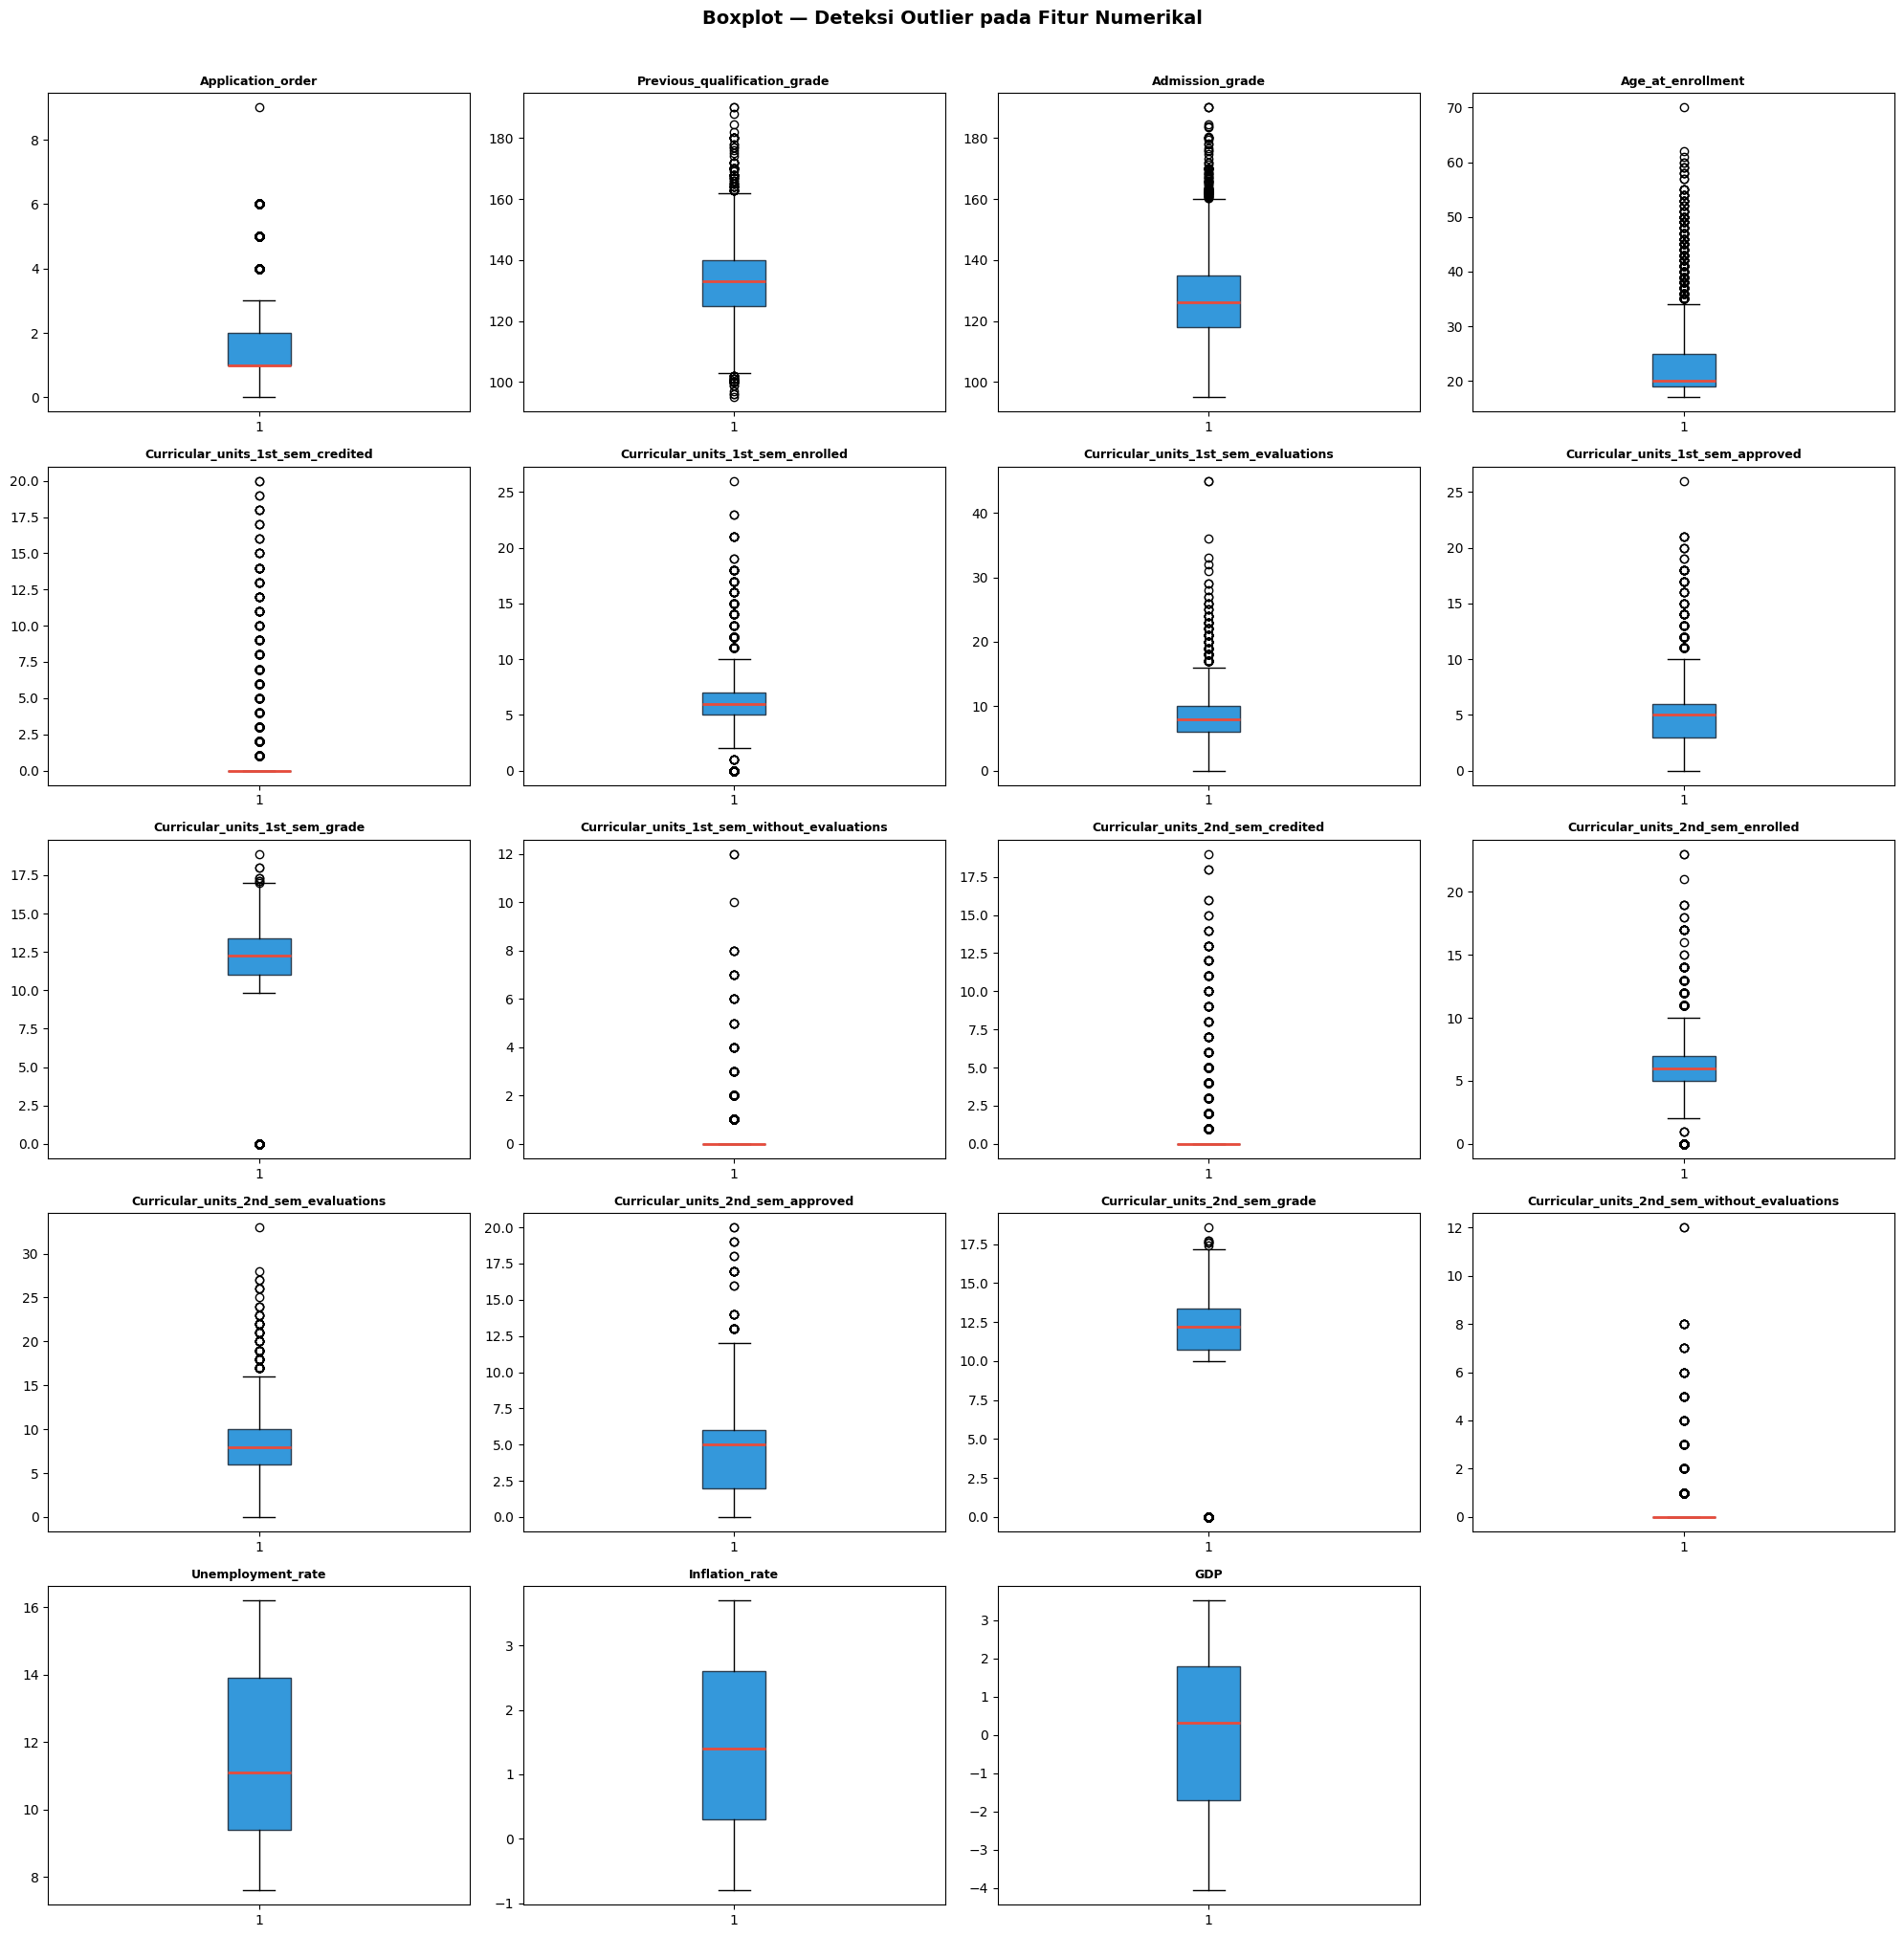

In [ ]:
# ============================================================
# Deteksi Outlier dengan Boxplot
# ============================================================
fig, axes = plt.subplots(5, 4, figsize=(20, 20)) # Changed to 5 rows, 4 columns
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#3498db', color='#2c3e50'),
                    medianprops=dict(color='#e74c3c', linewidth=2))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')

# Sembunyikan axes yang tidak terpakai
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot — Deteksi Outlier pada Fitur Numerikal', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('boxplot_outlier.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# Hitung Outlier dengan IQR
# ============================================================
print("=== Jumlah Outlier per Kolom (Metode IQR) ===")
outlier_summary = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        'Kolom': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Jumlah Outlier': n_outlier,
        'Outlier (%)': round(n_outlier / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Jumlah Outlier', ascending=False)
display(outlier_df)

=== Jumlah Outlier per Kolom (Metode IQR) ===


,Kolom,Q1,Q3,IQR,Lower Bound,Upper Bound,Jumlah Outlier,Outlier (%)
14,Curricular_units_2nd_sem_grade,10.75,13.33,2.58,6.87,17.21,877,19.82
8,Curricular_units_1st_sem_grade,11.00,13.40,2.40,7.40,17.00,726,16.41
4,Curricular_units_1st_sem_credited,0.00,0.00,0.00,0.00,0.00,577,13.04
0,Application_order,1.00,2.00,1.00,-0.50,3.50,541,12.23
10,Curricular_units_2nd_sem_credited,0.00,0.00,0.00,0.00,0.00,530,11.98
3,Age_at_enrollment,19.00,25.00,6.00,10.00,34.00,441,9.97
5,Curricular_units_1st_sem_enrolled,5.00,7.00,2.00,2.00,10.00,424,9.58
11,Curricular_units_2nd_sem_enrolled,5.00,7.00,2.00,2.00,10.00,369,8.34
9,Curricular_units_1st_sem_without_evaluations,0.00,0.00,0.00,0.00,0.00,294,6.65
15,Curricular_units_2nd_sem_without_evaluations,0.00,0.00,0.00,0.00,0.00,282,6.37


**Insight Deteksi Outlier**
*   **Banyak Outlier**: Sebanyak 16 dari 19 kolom numerikal teridentifikasi memiliki *outlier* menggunakan metode IQR. Beberapa kolom dengan outlier terbanyak adalah `Curricular_units_2nd_sem_grade`, `Curricular_units_1st_sem_grade`, `Curricular_units_1st_sem_credited`, dan `Application_order`.
*   **Implikasi**: Outlier dapat mempengaruhi kinerja model, terutama model yang sensitif terhadap distribusi data. Penanganan outlier (seperti *capping* atau transformasi) akan dibutuhkan.

### Distribusi Fitur

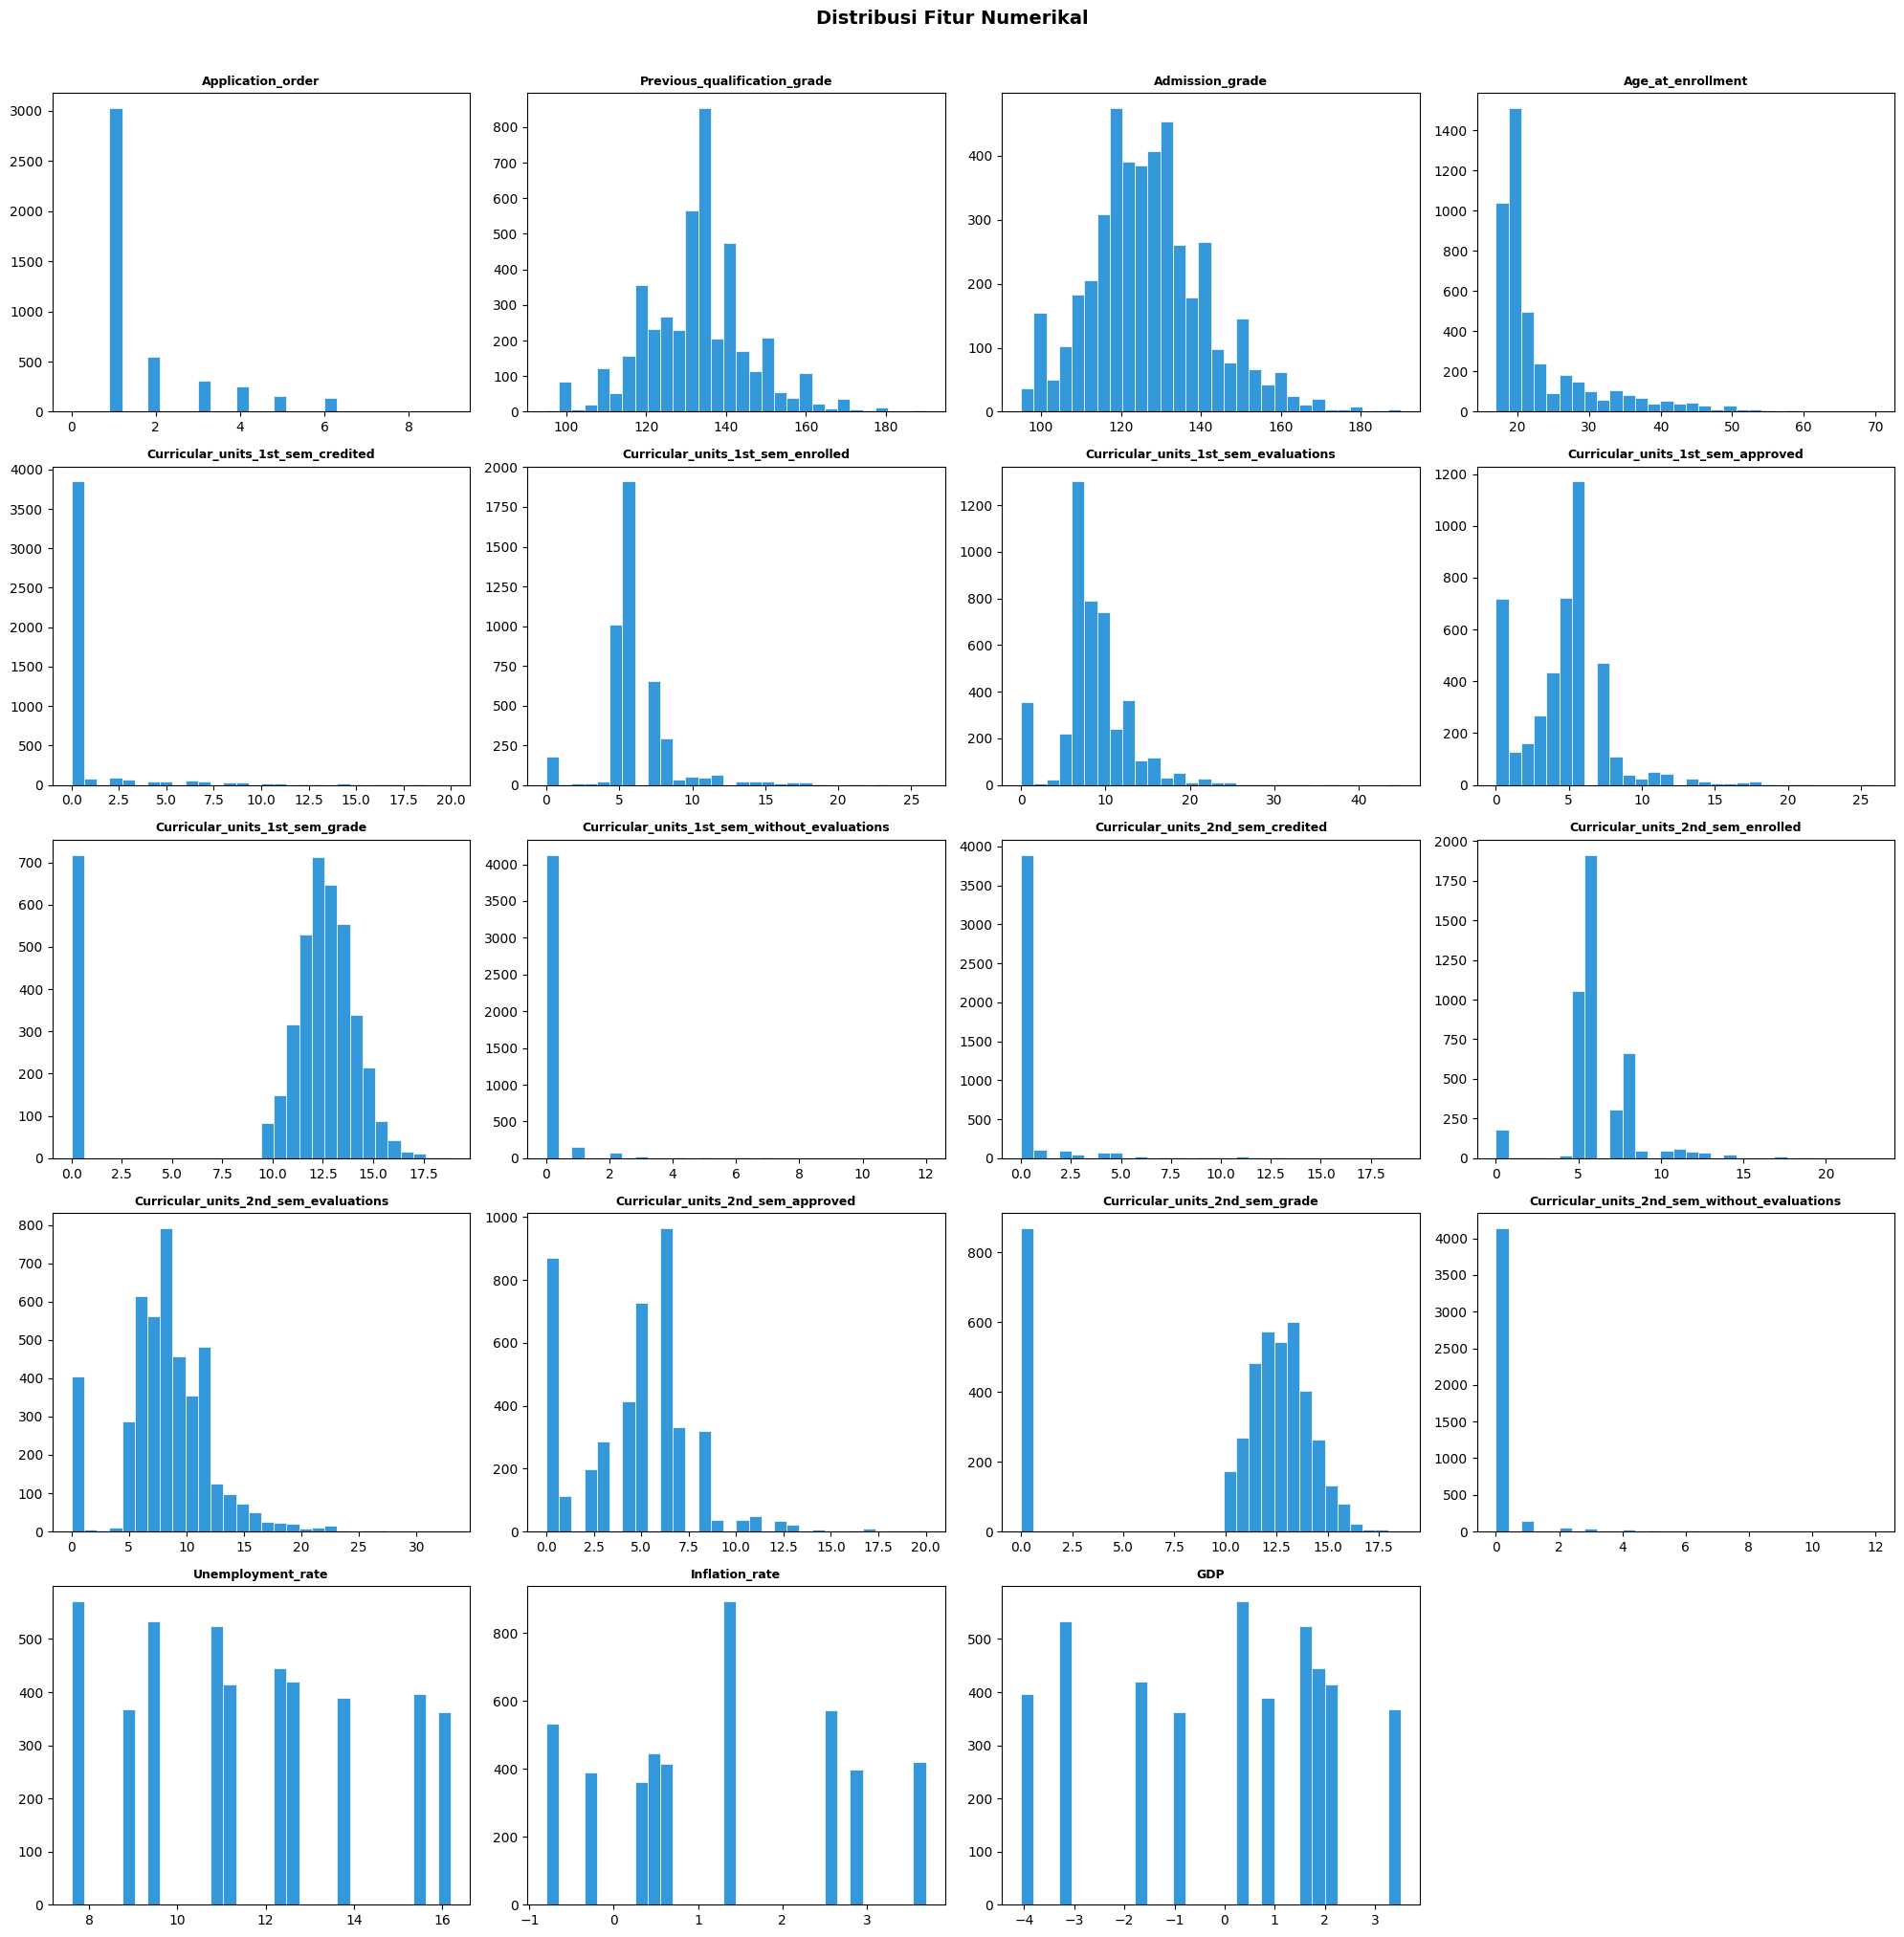

In [ ]:
# ============================================================
# Distribusi Fitur Numerikal (Histogram)
# ============================================================
fig, axes = plt.subplots(5, 4, figsize=(20, 20)) # Changed to 5 rows, 4 columns
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerikal', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('histogram_numerik.png', dpi=150, bbox_inches='tight')
plt.show()

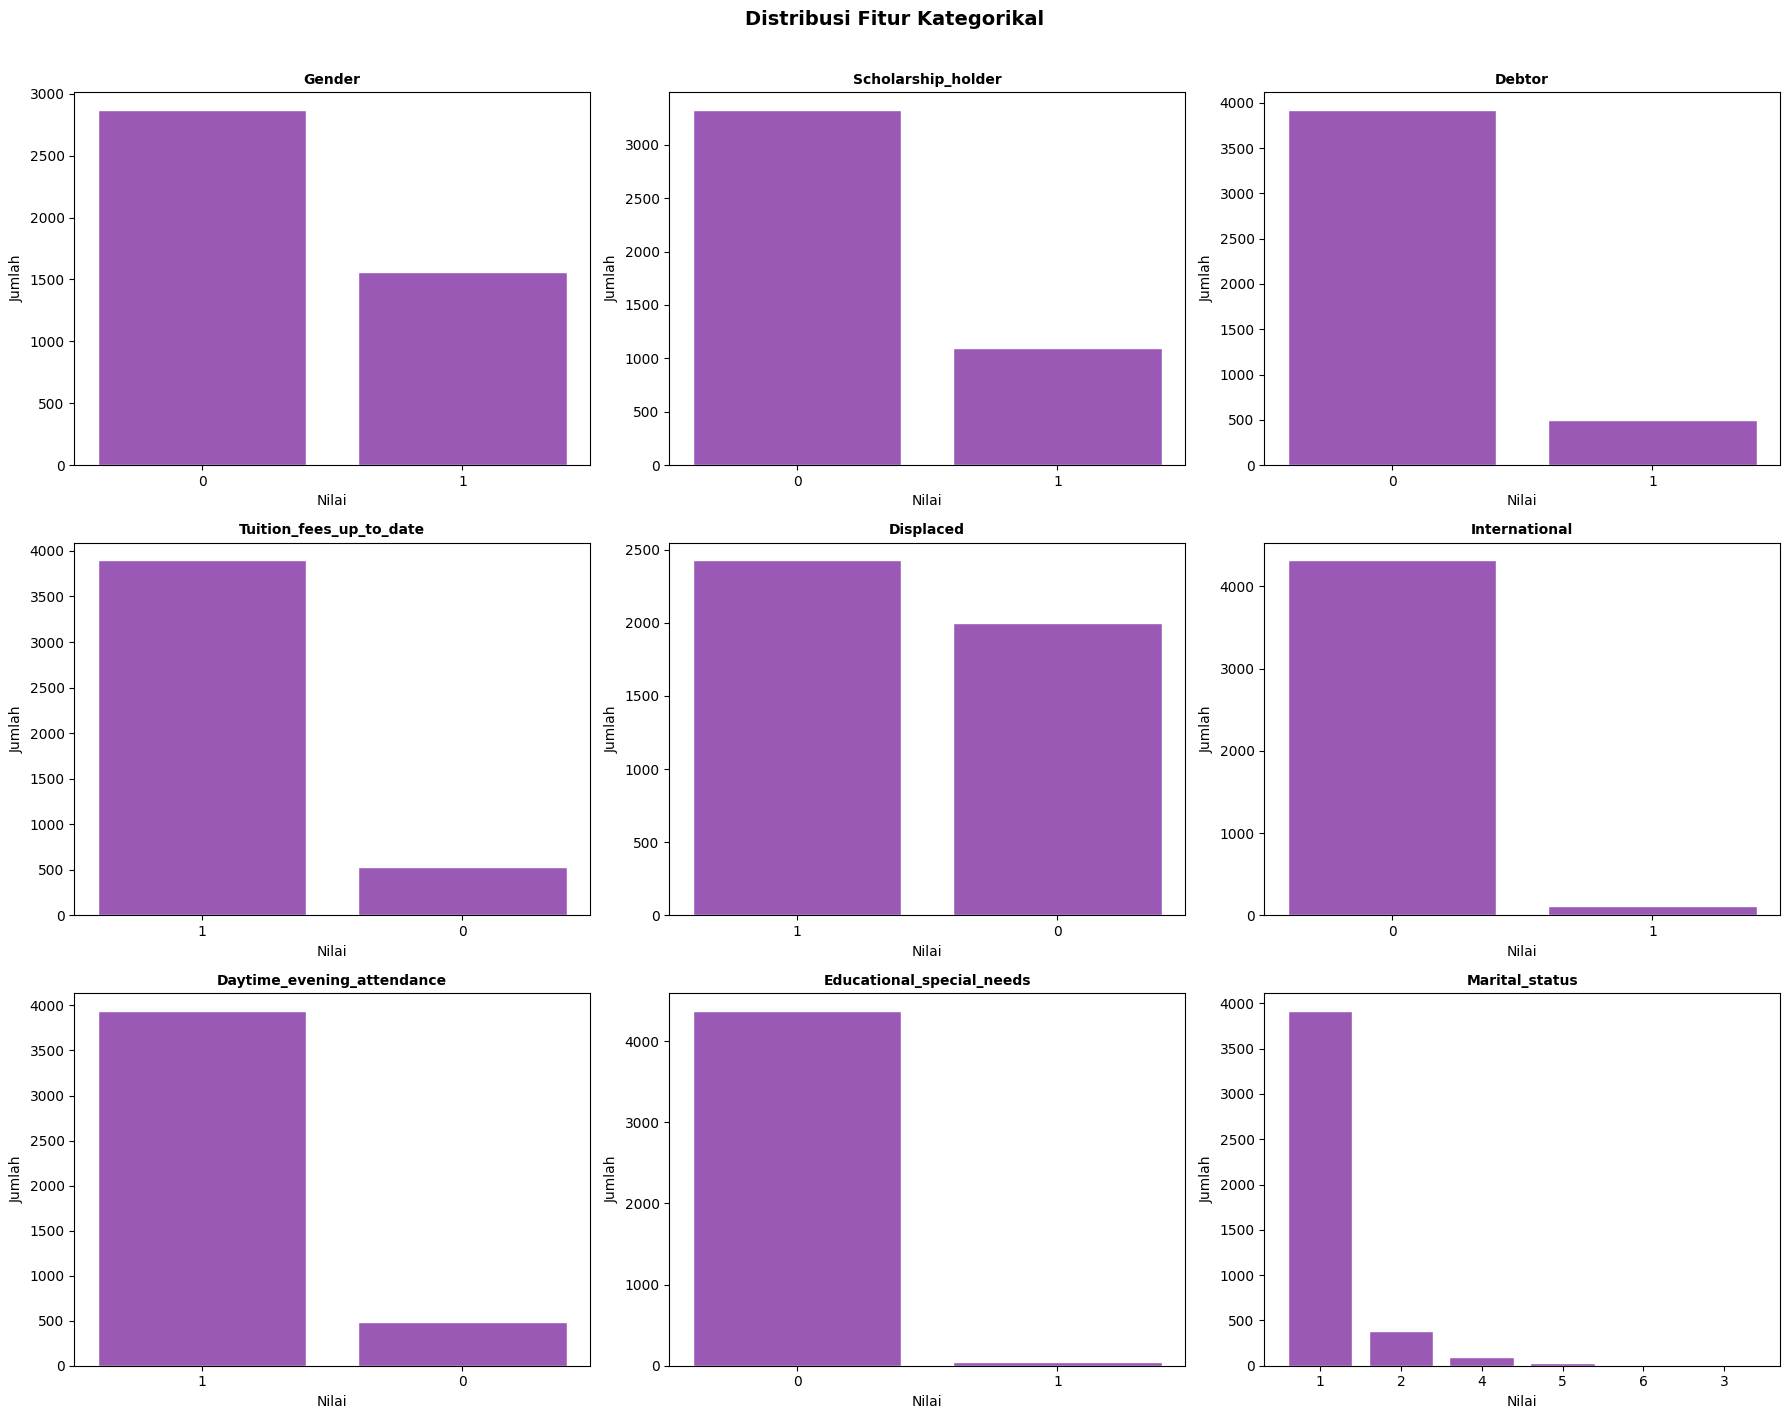

In [ ]:
# ============================================================
# Distribusi Fitur Kategorikal
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

# Pilih beberapa kolom kategorikal yang representatif
cat_sample = ['Gender', 'Scholarship_holder', 'Debtor',
              'Tuition_fees_up_to_date', 'Displaced', 'International',
              'Daytime_evening_attendance', 'Educational_special_needs', 'Marital_status']

for i, col in enumerate(cat_sample):
    counts = df[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, color='#9b59b6', edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Jumlah')

for j in range(len(cat_sample), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distribusi_kategorikal.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight Distribusi Fitur**
*   **Numerikal**: Histogram menunjukkan berbagai bentuk distribusi, ada yang cenderung normal, *skewed*, atau *multi-modal*. Hal ini memperkuat perlunya normalisasi/scaling pada fitur numerikal.
*   **Kategorikal**: Bar plot menunjukkan distribusi frekuensi untuk fitur kategorikal. Contohnya, mayoritas mahasiswa berjenis kelamin `Male` (Gender=1), banyak yang bukan penerima beasiswa (`Scholarship_holder`=0), dan sebagian besar tidak memiliki tunggakan (`Debtor`=0).

### Korelasi Antar Fitur Numerikal

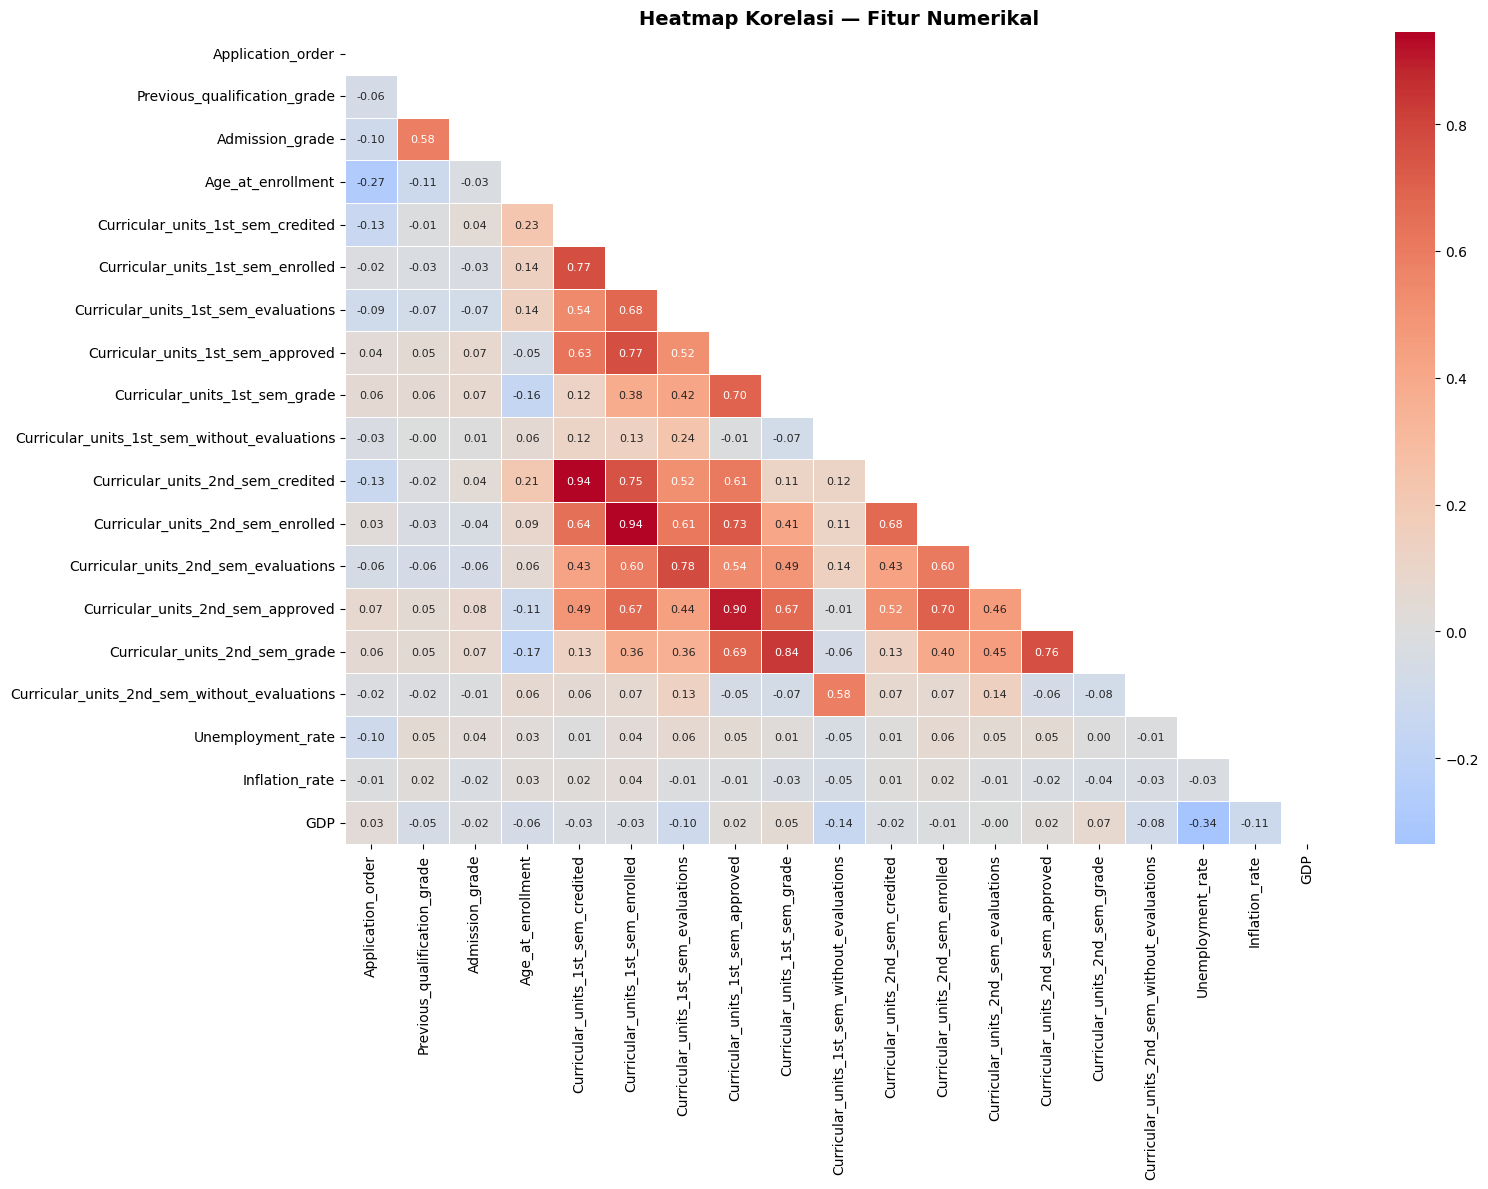

In [ ]:
# ============================================================
# Korelasi Antar Fitur Numerikal (Heatmap)
# ============================================================
plt.figure(figsize=(16, 12))
corr_matrix = df[numerical_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})

plt.title('Heatmap Korelasi — Fitur Numerikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight Korelasi Antar Fitur Numerikal**
*   **Korelasi Positif Kuat**: Terlihat korelasi positif yang kuat antara beberapa fitur akademik semester 1 dan semester 2 (misalnya, `Curricular_units_1st_sem_approved` dengan `Curricular_units_2nd_sem_approved`, `Curricular_units_1st_sem_grade` dengan `Curricular_units_2nd_sem_grade`). Ini wajar karena performa akademik cenderung konsisten.
*   **Korelasi Lemah/Sedang**: Banyak fitur yang memiliki korelasi rendah satu sama lain, menunjukkan bahwa mereka membawa informasi yang berbeda.

### Ringkasan Data Understanding



Fase **Data Understanding** telah memberikan wawasan mendalam tentang karakteristik dataset:

*   **Tipe Data & Struktur Dataset**:
    *   Dataset terdiri dari 4424 baris dan 37 kolom, dengan kombinasi tipe data `int64`, `float64`, dan satu kolom `object` (target `Status`).
    *   Banyak kolom `int64` yang sebenarnya bersifat kategorikal (misalnya, `Marital_status`, `Application_mode`).
    *   Beberapa fitur seperti `Admission_grade` dan `Previous_qualification_grade` memiliki banyak nilai unik, mengindikasikan sifat kontinu.

*   **Missing Values**:
    *   Dataset ini **bersih dari *missing values***, yang berarti tidak diperlukan langkah imputasi.

*   **Distribusi Target (Status)**:
    *   Kolom target `Status` sangat **tidak seimbang (imbalanced)**:
        *   `Graduate`: 2209 (49.9%)
        *   `Dropout`: 1421 (32.1%)
        *   `Enrolled`: 794 (17.9%)
    *   Ketidakseimbangan ini menjadi perhatian utama untuk tahap *modeling* dan memerlukan penanganan khusus (misalnya, SMOTE).

*   **Identifikasi Kolom Kategorikal vs Numerikal**:
    *   Telah diidentifikasi 17 kolom sebagai kategorikal dan 19 kolom sebagai numerikal, yang penting untuk langkah *preprocessing* selanjutnya.

*   **Statistik Deskriptif Kolom Numerikal**:
    *   Fitur numerikal menunjukkan rentang nilai yang bervariasi, dari yang kecil hingga besar, mengindikasikan perlunya *scaling*.
    *   Adanya perbedaan signifikan antara nilai min/max dan kuartil menunjukkan potensi *outlier*.

*   **Deteksi Outlier**:
    *   Sebanyak **16 dari 19 kolom numerikal teridentifikasi memiliki *outlier*** menggunakan metode IQR. Kolom seperti `Curricular_units_2nd_sem_grade` dan `Application_order` memiliki jumlah *outlier* yang signifikan.
    *   Penanganan *outlier* (seperti *capping*) akan diperlukan untuk meningkatkan kinerja model.

*   **Distribusi Fitur**:
    *   Histogram fitur numerikal menunjukkan berbagai bentuk distribusi (normal, *skewed*, *multi-modal*).
    *   Bar plot fitur kategorikal mengungkapkan distribusi frekuensi, misalnya, mayoritas mahasiswa adalah laki-laki, banyak yang tidak menerima beasiswa, dan sebagian besar tidak memiliki tunggakan.

*   **Korelasi Antar Fitur Numerikal**:
    *   Terdapat korelasi positif yang kuat antara performa akademik semester 1 dan semester 2, yang wajar.
    *   Banyak fitur memiliki korelasi rendah, menunjukkan bahwa mereka membawa informasi yang berbeda dan dapat berkontribusi pada model.

**Kesimpulan dari Data Understanding**:
Dataset ini kaya informasi, namun memiliki tantangan utama berupa *class imbalance* pada target dan keberadaan *outlier* yang signifikan. Identifikasi yang jelas antara fitur kategorikal dan numerikal, serta pemahaman mendalam tentang distribusi dan korelasi data, menjadi fondasi penting untuk tahap *preprocessing* dan *modeling* selanjutnya.

## EDA

In [ ]:
# ============================================================
# Setup EDA
# ============================================================
# Tambahkan kolom label numerik untuk kemudahan analisis
status_order = ['Dropout', 'Enrolled', 'Graduate']
colors_status = {'Dropout': '#e74c3c', 'Enrolled': '#3498db', 'Graduate': '#2ecc71'}

print("✅ Setup EDA siap!")

✅ Setup EDA siap!


### Dropout Rate per Fitur Kategorikal Penting

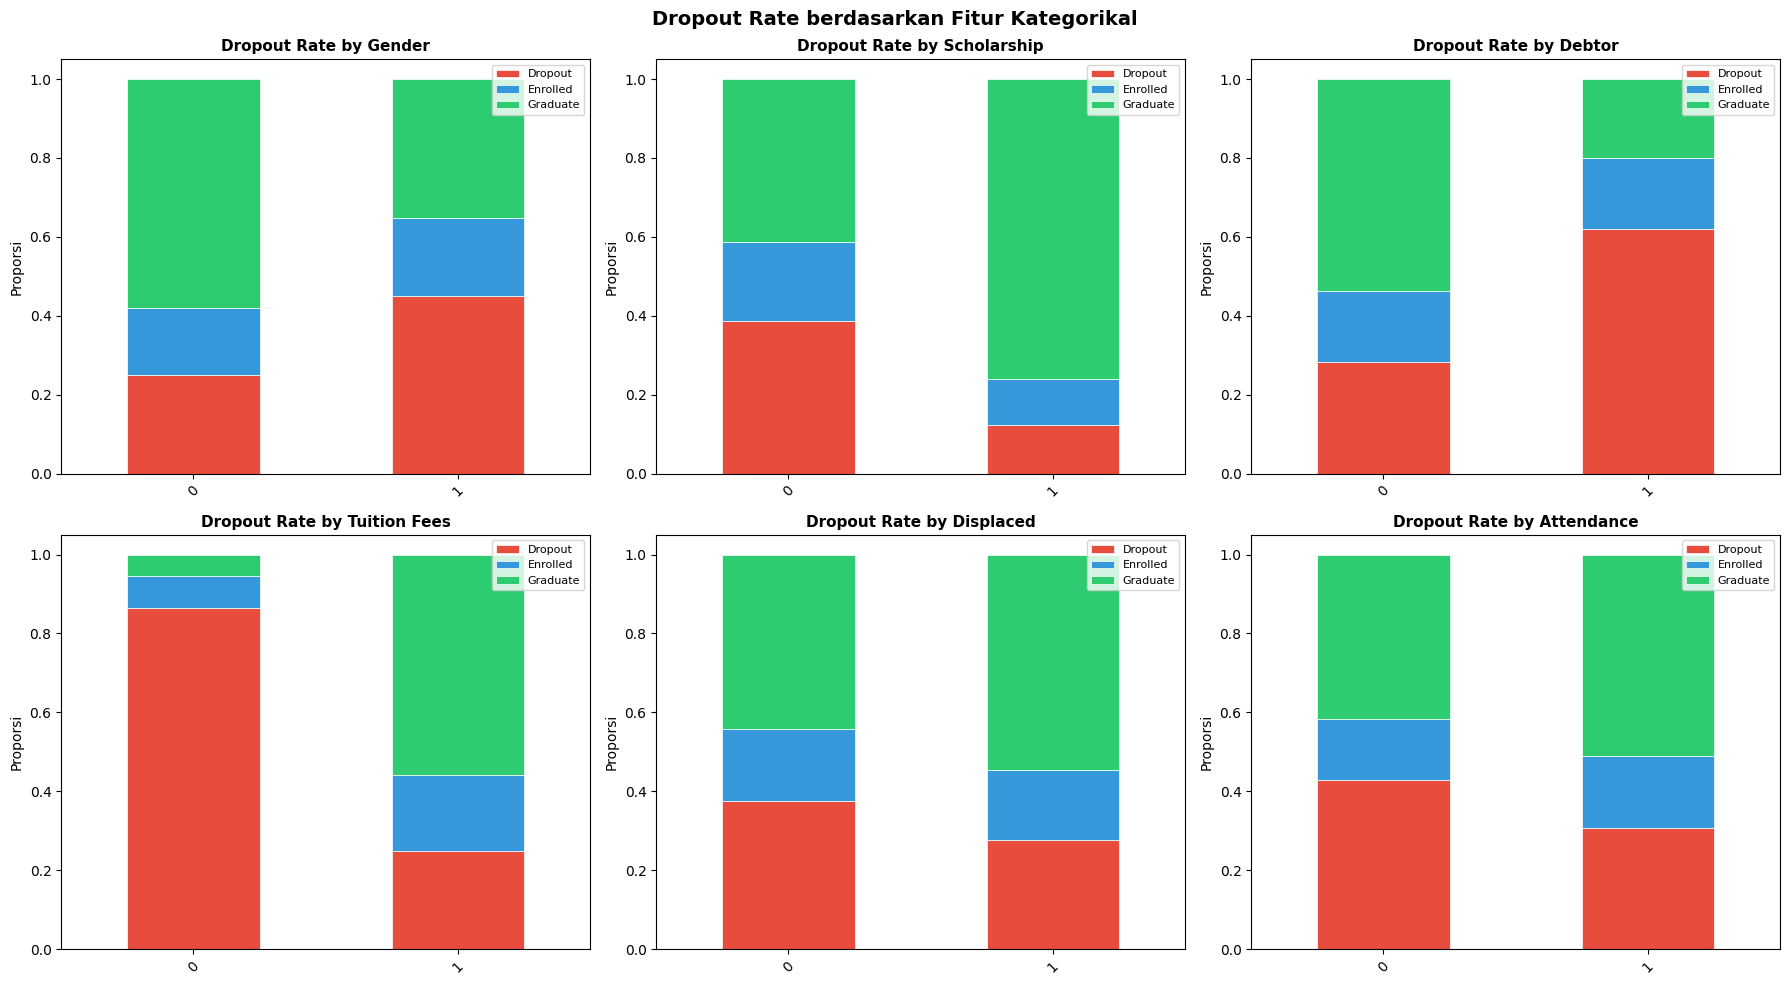

In [ ]:
# ============================================================
# Dropout Rate per Fitur Kategorikal Penting
# ============================================================
def plot_dropout_rate(col, title, ax, top_n=None):
    grouped = df.groupby(col)['Status'].value_counts(normalize=True).unstack().fillna(0)
    if top_n:
        top_cats = df[col].value_counts().head(top_n).index
        grouped = grouped.loc[grouped.index.isin(top_cats)]
    grouped = grouped.reindex(columns=['Dropout', 'Enrolled', 'Graduate'], fill_value=0)
    grouped.plot(kind='bar', stacked=True, ax=ax,
                 color=[colors_status[c] for c in grouped.columns],
                 edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Proporsi')
    ax.set_xlabel('')
    ax.legend(loc='upper right', fontsize=8)
    ax.tick_params(axis='x', rotation=45)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_dropout_rate('Gender', 'Dropout Rate by Gender', axes[0, 0])
plot_dropout_rate('Scholarship_holder', 'Dropout Rate by Scholarship', axes[0, 1])
plot_dropout_rate('Debtor', 'Dropout Rate by Debtor', axes[0, 2])
plot_dropout_rate('Tuition_fees_up_to_date', 'Dropout Rate by Tuition Fees', axes[1, 0])
plot_dropout_rate('Displaced', 'Dropout Rate by Displaced', axes[1, 1])
plot_dropout_rate('Daytime_evening_attendance', 'Dropout Rate by Attendance', axes[1, 2])

plt.suptitle('Dropout Rate berdasarkan Fitur Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_kategorikal_dropout.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight Dropout Rate per Fitur Kategorikal Penting**
*   **Gender**: Ada perbedaan minor, tetapi tidak terlalu signifikan dalam proporsi dropout antara gender.
*   **Scholarship_holder**: Mahasiswa yang mendapatkan beasiswa (`Scholarship_holder=1`) memiliki *dropout rate* yang jauh lebih rendah dibandingkan yang tidak (`Scholarship_holder=0`). Ini menunjukkan peran penting dukungan finansial.
*   **Debtor**: Mahasiswa yang memiliki tunggakan (`Debtor=1`) menunjukkan *dropout rate* yang sangat tinggi dibandingkan yang tidak (`Debtor=0`).
*   **Tuition_fees_up_to_date**: Mahasiswa yang tidak membayar uang kuliah tepat waktu (`Tuition_fees_up_to_date=0`) memiliki *dropout rate* yang jauh lebih tinggi. Ini sangat mirip dengan insight dari kolom `Debtor`.
*   **Displaced**: Mahasiswa yang `Displaced=1` (mungkin bermigrasi atau pindah tempat) memiliki sedikit lebih tinggi *dropout rate* dibandingkan yang tidak.
*   **Daytime_evening_attendance**: Mahasiswa yang mengikuti kelas malam (`Daytime_evening_attendance=0`) memiliki *dropout rate* yang lebih tinggi dibandingkan dengan mahasiswa kelas pagi/siang (`Daytime_evening_attendance=1`).

### Analisis Usia saat Pendaftaran vs Status

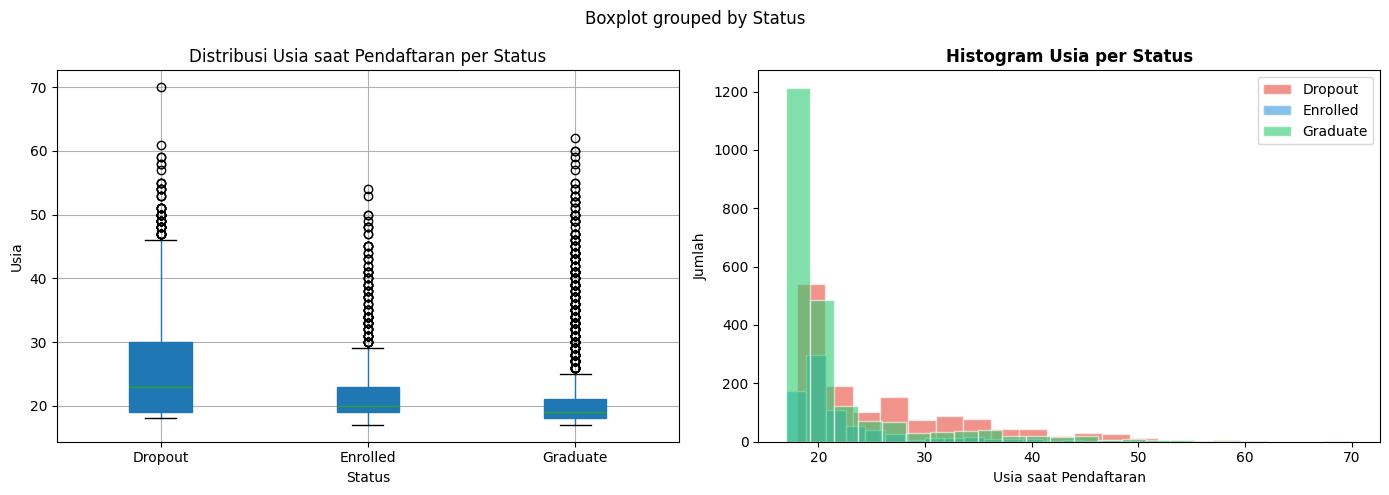

=== Rata-rata Usia per Status ===
Status
Dropout     26.07
Enrolled    22.37
Graduate    21.78
Name: Age_at_enrollment, dtype: float64


In [ ]:
# ============================================================
# Analisis Usia saat Pendaftaran vs Status
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot usia per status
df.boxplot(column='Age_at_enrollment', by='Status', ax=axes[0],
           patch_artist=True)
axes[0].set_title('Distribusi Usia saat Pendaftaran per Status', fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Usia')
plt.sca(axes[0])
plt.title('Distribusi Usia saat Pendaftaran per Status')

# Histogram usia per status
for status in status_order:
    subset = df[df['Status'] == status]['Age_at_enrollment']
    axes[1].hist(subset, bins=20, alpha=0.6, label=status,
                 color=colors_status[status], edgecolor='white')
axes[1].set_title('Histogram Usia per Status', fontweight='bold')
axes[1].set_xlabel('Usia saat Pendaftaran')
axes[1].set_ylabel('Jumlah')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_usia_status.png', dpi=150, bbox_inches='tight')
plt.show()

# Rata-rata usia per status
print("=== Rata-rata Usia per Status ===")
print(df.groupby('Status')['Age_at_enrollment'].mean().round(2))

**Insight Analisis Usia saat Pendaftaran vs Status**
*   **Distribusi Usia**: Mahasiswa yang **Dropout** cenderung memiliki rata-rata usia saat pendaftaran yang lebih tinggi (sekitar 26 tahun) dibandingkan dengan mahasiswa yang **Enrolled** (sekitar 22.37 tahun) atau **Graduate** (sekitar 21.78 tahun).
*   **Implikasi**: Usia yang lebih tua saat pendaftaran bisa menjadi faktor risiko dropout.

### Performa Akademik Semester 1 & 2 vs Status

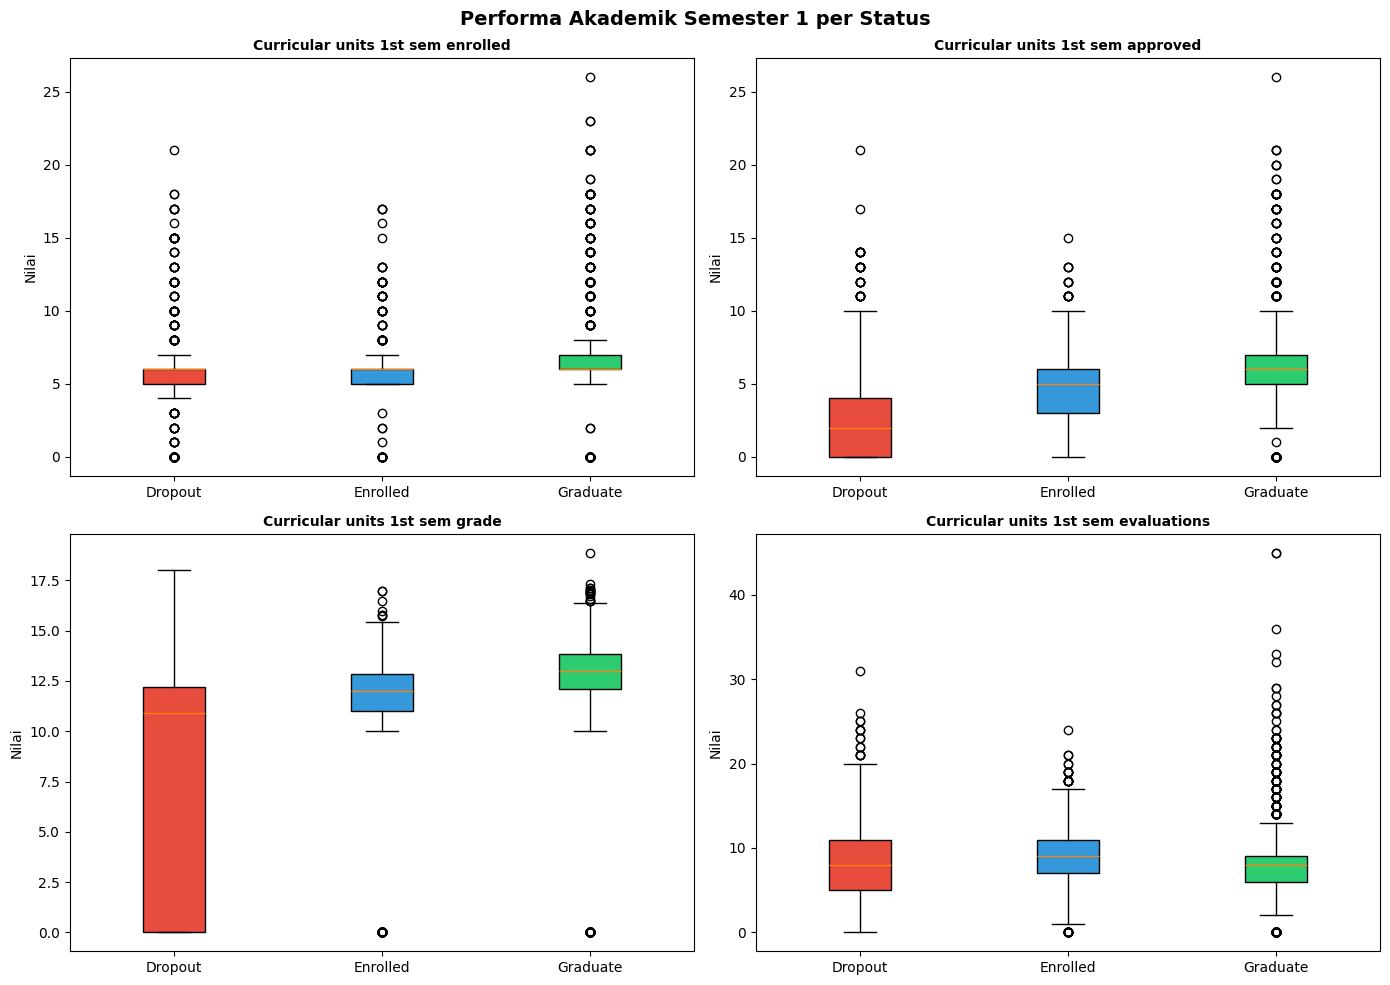

=== Rata-rata Performa Akademik Semester 1 per Status ===


,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_evaluations
Status,,,,
Dropout,5.82,2.55,7.26,7.75
Enrolled,5.96,4.32,11.13,9.34
Graduate,6.67,6.23,12.64,8.28


In [ ]:
# ============================================================
# Performa Akademik Semester 1 vs Status
# ============================================================
akademik_cols = [
    'Curricular_units_1st_sem_enrolled',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_1st_sem_evaluations'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(akademik_cols):
    data_per_status = [df[df['Status'] == s][col].values for s in status_order]
    bp = axes[i].boxplot(data_per_status, labels=status_order, patch_artist=True)
    for patch, status in zip(bp['boxes'], status_order):
        patch.set_facecolor(colors_status[status])
    axes[i].set_title(col.replace('_', ' '), fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Nilai')

plt.suptitle('Performa Akademik Semester 1 per Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_akademik_sem1.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Rata-rata Performa Akademik Semester 1 per Status ===")
display(df.groupby('Status')[akademik_cols].mean().round(2))

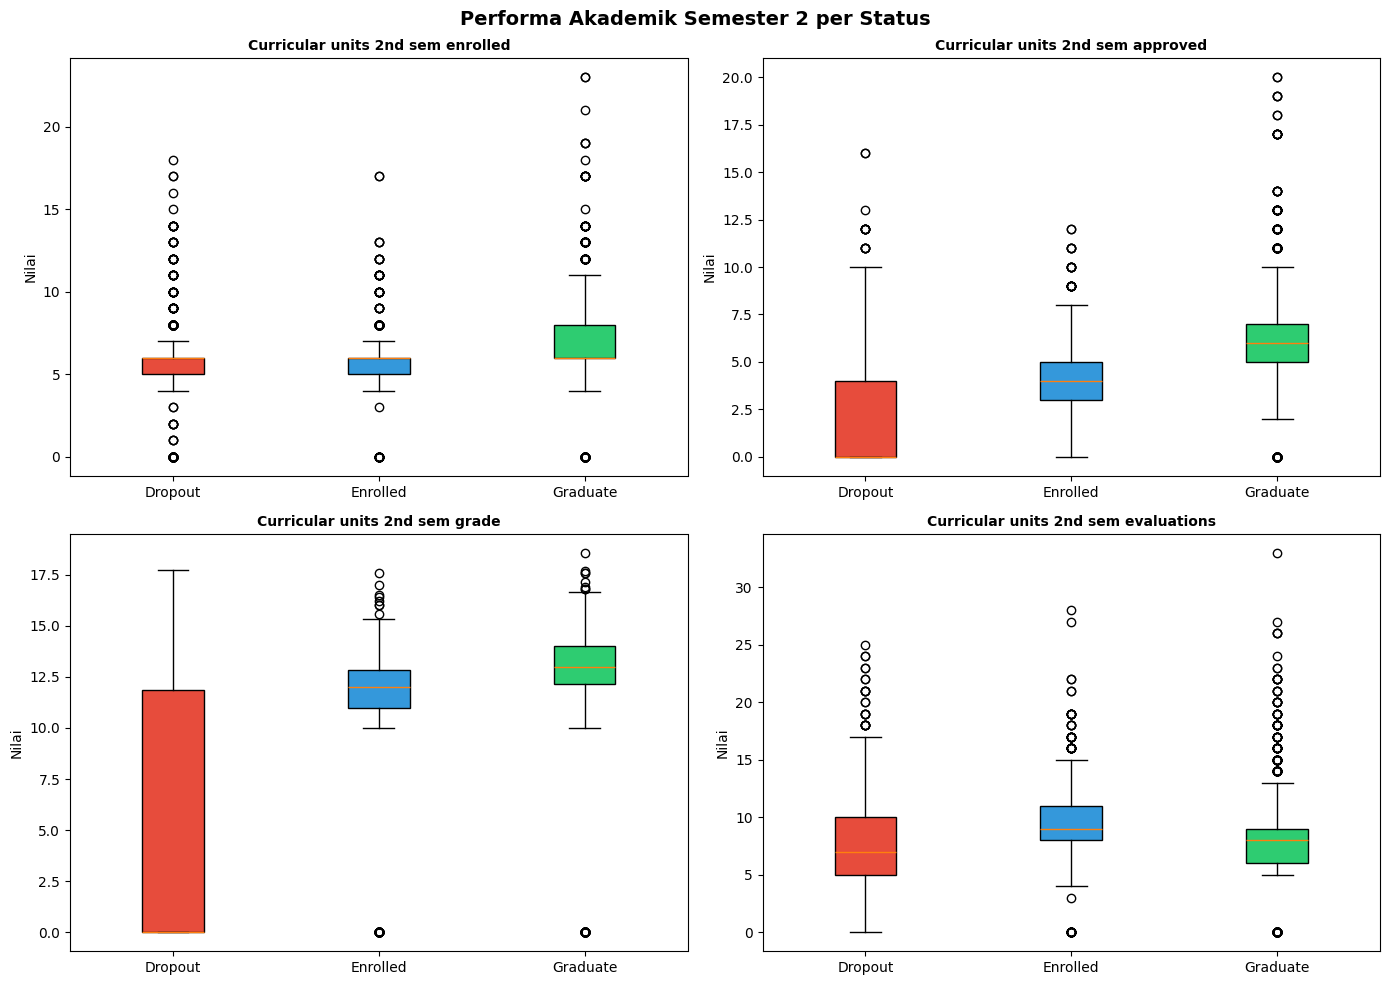

=== Rata-rata Performa Akademik Semester 2 per Status ===


,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_evaluations
Status,,,,
Dropout,5.78,1.94,5.90,7.17
Enrolled,5.94,4.06,11.12,9.44
Graduate,6.63,6.18,12.70,8.14


In [ ]:
# ============================================================
# Performa Akademik Semester 2 vs Status
# ============================================================
akademik_cols_2 = [
    'Curricular_units_2nd_sem_enrolled',
    'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade',
    'Curricular_units_2nd_sem_evaluations'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(akademik_cols_2):
    data_per_status = [df[df['Status'] == s][col].values for s in status_order]
    bp = axes[i].boxplot(data_per_status, labels=status_order, patch_artist=True)
    for patch, status in zip(bp['boxes'], status_order):
        patch.set_facecolor(colors_status[status])
    axes[i].set_title(col.replace('_', ' '), fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Nilai')

plt.suptitle('Performa Akademik Semester 2 per Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_akademik_sem2.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Rata-rata Performa Akademik Semester 2 per Status ===")
display(df.groupby('Status')[akademik_cols_2].mean().round(2))

**Insight Performa Akademik Semester 1 & 2 vs Status**
*   **Units Approved**: Mahasiswa yang **Dropout** secara signifikan memiliki jumlah unit kurikuler yang disetujui (`Curricular_units_1st/2nd_sem_approved`) yang jauh lebih rendah di kedua semester dibandingkan dengan mahasiswa yang Enrolled dan Graduate.
*   **Nilai Rata-rata**: Rata-rata nilai (`Curricular_units_1st/2nd_sem_grade`) mahasiswa Dropout juga secara konsisten lebih rendah.
*   **Evaluasi**: Mahasiswa Dropout juga menunjukkan jumlah evaluasi yang diikuti lebih sedikit (`Curricular_units_1st/2nd_sem_evaluations`).
*   **Kesimpulan**: Performa akademik yang buruk di semester awal merupakan indikator kuat untuk potensi dropout.

### Faktor Sosial-Ekonomi vs Status

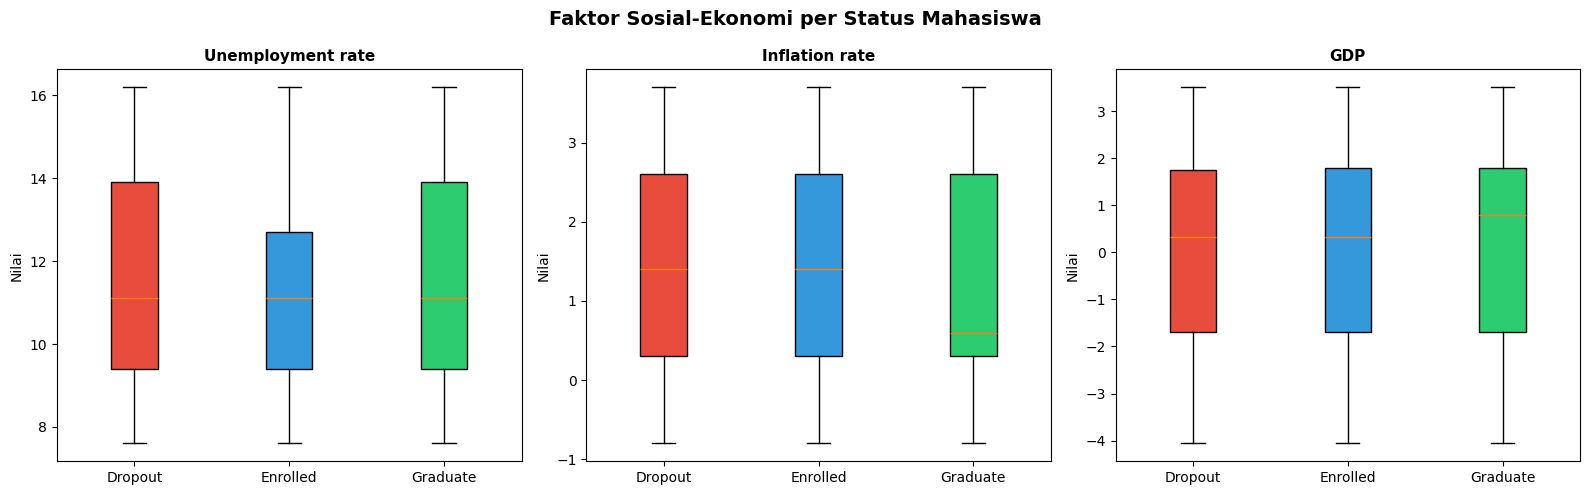

=== Rata-rata Faktor Sosial-Ekonomi per Status ===


,Unemployment_rate,Inflation_rate,GDP
Status,,,
Dropout,11.6164,1.2840,-0.1509
Enrolled,11.2725,1.2117,0.0533
Graduate,11.6393,1.1979,0.0818


In [ ]:
# ============================================================
# Faktor Sosial-Ekonomi vs Status
# ============================================================
ekonomi_cols = ['Unemployment_rate', 'Inflation_rate', 'GDP']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(ekonomi_cols):
    data_per_status = [df[df['Status'] == s][col].values for s in status_order]
    bp = axes[i].boxplot(data_per_status, labels=status_order, patch_artist=True)
    for patch, status in zip(bp['boxes'], status_order):
        patch.set_facecolor(colors_status[status])
    axes[i].set_title(col.replace('_', ' '), fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Nilai')

plt.suptitle('Faktor Sosial-Ekonomi per Status Mahasiswa', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_sosial_ekonomi.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Rata-rata Faktor Sosial-Ekonomi per Status ===")
display(df.groupby('Status')[ekonomi_cols].mean().round(4))

**Insight Faktor Sosial-Ekonomi vs Status**
*   **Unemployment_rate, Inflation_rate, GDP**: Boxplot dan rata-rata dari ketiga fitur ini menunjukkan distribusi yang sangat mirip di antara ketiga status mahasiswa (Dropout, Enrolled, Graduate).
*   **Kesimpulan**: Faktor-faktor sosial-ekonomi makro ini tampaknya tidak memiliki perbedaan yang signifikan dalam membedakan status mahasiswa dalam dataset ini, menunjukkan bahwa kondisi ekonomi umum mungkin kurang relevan dibandingkan faktor personal atau akademik.

### Admission Grade & Previous Qualification Grade vs Status

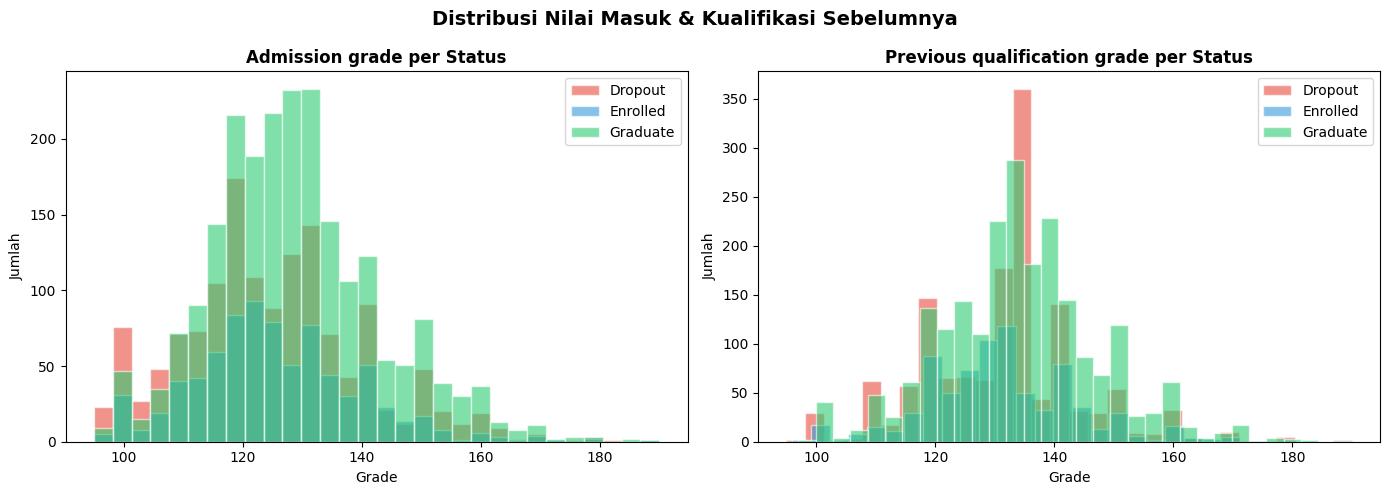

=== Rata-rata Grade per Status ===


,Admission_grade,Previous_qualification_grade
Status,,
Dropout,124.96,131.11
Enrolled,125.53,131.21
Graduate,128.79,134.08


In [ ]:
# ============================================================
# Admission Grade & Previous Qualification Grade vs Status
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

grade_cols = ['Admission_grade', 'Previous_qualification_grade']

for i, col in enumerate(grade_cols):
    for status in status_order:
        subset = df[df['Status'] == status][col]
        axes[i].hist(subset, bins=30, alpha=0.6, label=status,
                     color=colors_status[status], edgecolor='white')
    axes[i].set_title(f'{col.replace("_", " ")} per Status', fontweight='bold')
    axes[i].set_xlabel('Grade')
    axes[i].set_ylabel('Jumlah')
    axes[i].legend()

plt.suptitle('Distribusi Nilai Masuk & Kualifikasi Sebelumnya', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_grade_masuk.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Rata-rata Grade per Status ===")
display(df.groupby('Status')[grade_cols].mean().round(2))

**Insight Admission Grade & Previous Qualification Grade vs Status**
*   **Admission_grade**: Mahasiswa yang Dropout cenderung memiliki nilai masuk (`Admission_grade`) yang sedikit lebih rendah dibandingkan dengan Enrolled dan Graduate.
*   **Previous_qualification_grade**: Serupa, nilai kualifikasi sebelumnya (`Previous_qualification_grade`) mahasiswa Dropout juga sedikit lebih rendah.
*   **Implikasi**: Nilai masuk dan kualifikasi sebelumnya memberikan indikasi awal potensi keberhasilan siswa.

### Dropout Rate per Course (Top 10)

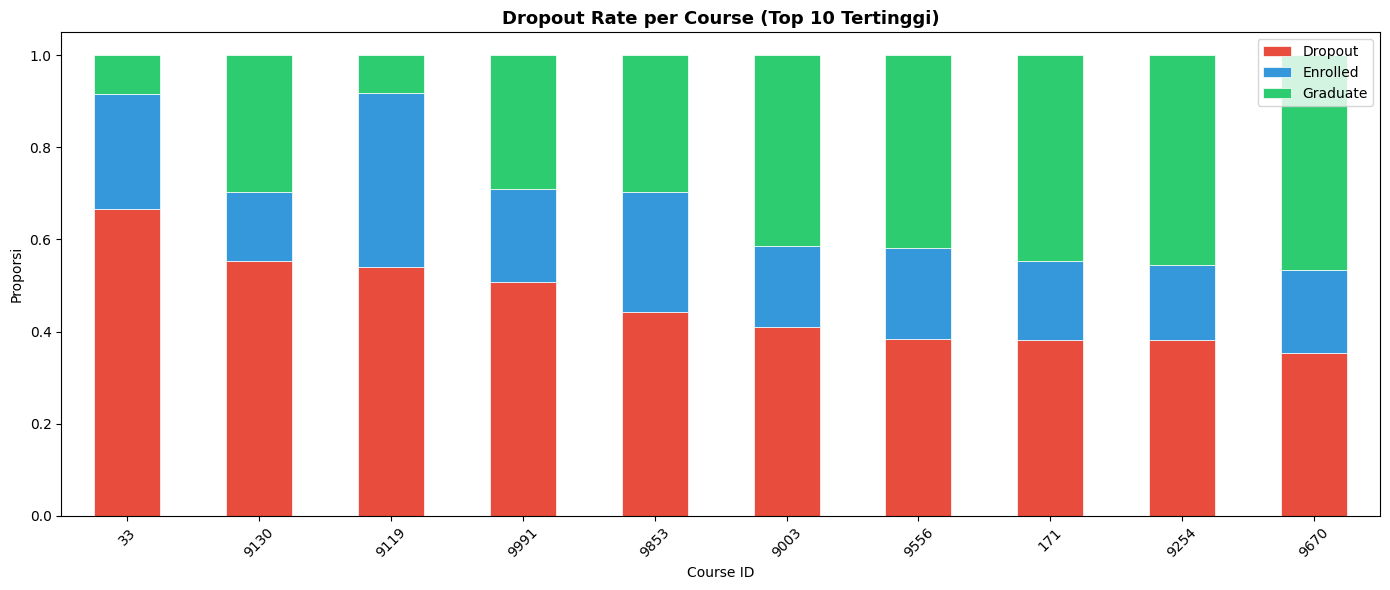

In [ ]:
# ============================================================
# Dropout Rate per Course (Top 10)
# ============================================================
course_dropout = df.groupby('Course')['Status'].value_counts(normalize=True).unstack().fillna(0)
course_dropout = course_dropout.reindex(columns=['Dropout', 'Enrolled', 'Graduate'], fill_value=0)
course_dropout = course_dropout.sort_values('Dropout', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(14, 6))
course_dropout.plot(kind='bar', stacked=True, ax=ax,
                    color=[colors_status[c] for c in course_dropout.columns],
                    edgecolor='white', linewidth=0.5)
ax.set_title('Dropout Rate per Course (Top 10 Tertinggi)', fontsize=13, fontweight='bold')
ax.set_xlabel('Course ID')
ax.set_ylabel('Proporsi')
ax.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('eda_dropout_per_course.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight Dropout Rate per Course (Top 10)**
*   **Variasi Kursus**: Terdapat variasi yang signifikan dalam *dropout rate* antar program studi (`Course`). Beberapa kursus memiliki proporsi dropout yang sangat tinggi (misalnya Course ID 33, 9130, 9119).
*   **Insight**: Mengidentifikasi kursus-kursus dengan *dropout rate* tinggi dapat membantu institusi untuk mengalokasikan sumber daya atau intervensi khusus pada program tersebut.

### Korelasi Fitur Numerikal dengan Dropout (Binary)

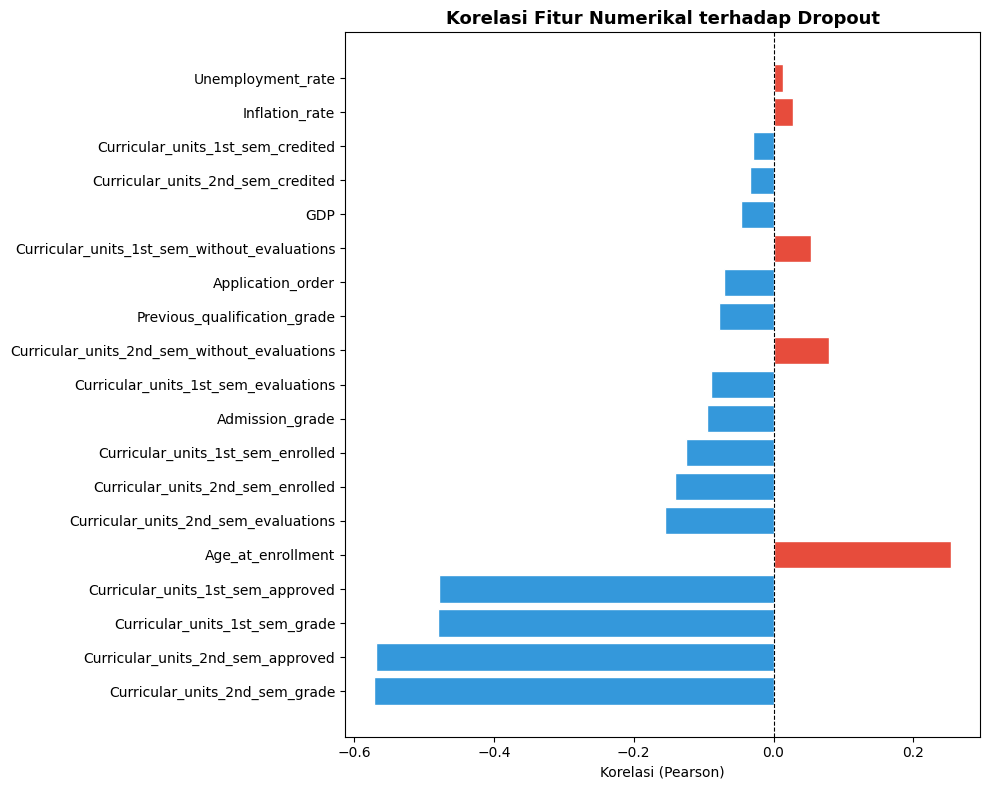

=== Top 10 Fitur paling berkorelasi dengan Dropout ===
Curricular_units_2nd_sem_grade         -0.5718
Curricular_units_2nd_sem_approved      -0.5695
Curricular_units_1st_sem_grade         -0.4807
Curricular_units_1st_sem_approved      -0.4791
Age_at_enrollment                       0.2542
Curricular_units_2nd_sem_evaluations   -0.1550
Curricular_units_2nd_sem_enrolled      -0.1415
Curricular_units_1st_sem_enrolled      -0.1246
Admission_grade                        -0.0958
Curricular_units_1st_sem_evaluations   -0.0901
Name: is_dropout, dtype: float64


In [ ]:
# ============================================================
# Korelasi Fitur Numerikal dengan Dropout (Binary)
# ============================================================
df_corr = df.copy()
df_corr['is_dropout'] = (df_corr['Status'] == 'Dropout').astype(int)

corr_dropout = df_corr[numerical_cols + ['is_dropout']].corr()['is_dropout'].drop('is_dropout')
corr_dropout = corr_dropout.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ['#e74c3c' if v > 0 else '#3498db' for v in corr_dropout.values]
ax.barh(corr_dropout.index, corr_dropout.values, color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Korelasi Fitur Numerikal terhadap Dropout', fontsize=13, fontweight='bold')
ax.set_xlabel('Korelasi (Pearson)')
plt.tight_layout()
plt.savefig('eda_korelasi_dropout.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Top 10 Fitur paling berkorelasi dengan Dropout ===")
print(corr_dropout.head(10).round(4))

**Insight Korelasi Fitur Numerikal dengan Dropout (Binary)**
*   **Korelasi Negatif Kuat**: Fitur-fitur akademik seperti `Curricular_units_2nd_sem_grade`, `Curricular_units_2nd_sem_approved`, `Curricular_units_1st_sem_grade`, dan `Curricular_units_1st_sem_approved` menunjukkan korelasi negatif yang kuat dengan `is_dropout` (semakin tinggi nilai akademik, semakin kecil kemungkinan dropout).
*   **Korelasi Positif Kuat**: `Age_at_enrollment` memiliki korelasi positif yang signifikan dengan `is_dropout` (semakin tua usia pendaftaran, semakin tinggi kemungkinan dropout).
*   **Kesimpulan**: Korelasi ini mengkonfirmasi temuan dari analisis sebelumnya dan menyoroti bahwa faktor akademik dan usia merupakan prediktor paling dominan terhadap status dropout.

### Ringkasan EDA

Fase EDA telah mengungkap beberapa pola dan hubungan penting dalam dataset yang sangat relevan untuk prediksi *dropout*:

1. Dropout Rate per Fitur Kategorikal Penting
*   **Scholarship_holder**: Mahasiswa penerima beasiswa memiliki *dropout rate* yang jauh lebih rendah. Ini menunjukkan dukungan finansial sangat krusial.
*   **Debtor & Tuition_fees_up_to_date**: Mahasiswa yang memiliki tunggakan atau tidak membayar uang kuliah tepat waktu menunjukkan *dropout rate* yang sangat tinggi, menegaskan risiko finansial.
*   **Daytime_evening_attendance**: Mahasiswa kelas malam cenderung memiliki *dropout rate* lebih tinggi.
*   **Displaced, Educational_special_needs, International**: Fitur-fitur ini juga menunjukkan variasi, namun tidak sekuat faktor finansial dan akademik.

2. Analisis Usia saat Pendaftaran vs Status
*   Mahasiswa yang **Dropout** cenderung memiliki rata-rata usia saat pendaftaran yang lebih tinggi (sekitar 26 tahun) dibandingkan dengan mereka yang **Enrolled** atau **Graduate**. Usia yang lebih tua bisa menjadi faktor risiko.

3. Performa Akademik Semester 1 & 2 vs Status
*   **Curricular_units_approved & Grade**: Mahasiswa yang **Dropout** secara signifikan memiliki jumlah unit kurikuler yang disetujui dan rata-rata nilai (*grade*) yang jauh lebih rendah di kedua semester. Performa akademik yang buruk adalah indikator kuat untuk potensi *dropout*.
*   **Evaluations**: Mahasiswa *Dropout* juga cenderung mengikuti evaluasi lebih sedikit.

4. Faktor Sosial-Ekonomi vs Status
*   `Unemployment_rate`, `Inflation_rate`, `GDP` menunjukkan distribusi yang sangat mirip di antara semua status mahasiswa. Ini mengindikasikan bahwa faktor-faktor makroekonomi ini mungkin kurang relevan dalam memprediksi status mahasiswa dibandingkan faktor personal atau akademik.

5. Admission Grade & Previous Qualification Grade vs Status
*   Mahasiswa yang **Dropout** cenderung memiliki nilai masuk (`Admission_grade`) dan nilai kualifikasi sebelumnya (`Previous_qualification_grade`) yang sedikit lebih rendah. Ini memberikan indikasi awal potensi keberhasilan siswa.

6. Dropout Rate per Course (Top 10)
*   Terdapat variasi signifikan dalam *dropout rate* antar program studi (`Course`). Beberapa kursus memiliki proporsi *dropout* yang sangat tinggi, mengindikasikan perlunya perhatian khusus pada program-program tersebut.

7. Korelasi Fitur Numerikal dengan Dropout (Binary)
*   **Korelasi Negatif Kuat**: Fitur-fitur akademik (`Curricular_units_grade`, `Curricular_units_approved`) menunjukkan korelasi negatif yang kuat dengan *dropout* (semakin baik performa akademik, semakin kecil kemungkinan *dropout*).
*   **Korelasi Positif Kuat**: `Age_at_enrollment` memiliki korelasi positif yang signifikan dengan *dropout* (semakin tua usia pendaftaran, semakin tinggi kemungkinan *dropout*).

**Kesimpulan dari EDA**:
EDA menggarisbawahi bahwa **performa akademik**, **faktor finansial** (tunggakan, beasiswa), dan **usia saat pendaftaran** adalah prediktor paling dominan terhadap status *dropout*. Fitur-fitur ini akan menjadi sangat penting dalam membangun model prediktif. Sementara itu, faktor makroekonomi dan beberapa fitur lainnya menunjukkan dampak yang lebih kecil.

## Data Preprocessing

### Encode Target

In [ ]:
# ============================================================
# Encode Target (Label Encoding)
# ============================================================
from sklearn.preprocessing import LabelEncoder

df_clean = df.copy()

# Encode target: Dropout=0, Enrolled=1, Graduate=2
le_target = LabelEncoder()
df_clean['Status_encoded'] = le_target.fit_transform(df_clean['Status'])

print("=== Mapping Encoding Target ===")
for cls, enc in zip(le_target.classes_, le_target.transform(le_target.classes_)):
    print(f"  {cls} → {enc}")

print("\n=== Distribusi Target Setelah Encoding ===")
print(df_clean['Status_encoded'].value_counts().sort_index())

=== Mapping Encoding Target ===
  Dropout → 0
  Enrolled → 1
  Graduate → 2

=== Distribusi Target Setelah Encoding ===
Status_encoded
0    1421
1     794
2    2209
Name: count, dtype: int64


**Insight Encode Target**
*   **Tujuan**: Mengubah variabel target kategorikal (`Status`) menjadi representasi numerik (`Status_encoded`). Ini diperlukan karena sebagian besar algoritma *machine learning* bekerja dengan input numerik.
*   **Mapping**: `Dropout` menjadi 0, `Enrolled` menjadi 1, dan `Graduate` menjadi 2. Urutan ini penting jika model mengasumsikan adanya hubungan ordinal, meskipun untuk klasifikasi *multiclass* tanpa asumsi tersebut, urutan ini mungkin tidak terlalu krusial.
*   **Verifikasi**: Distribusi kelas setelah *encoding* tetap sama, memastikan tidak ada perubahan pada proporsi kelas.

### Feature Engineering

In [ ]:
# ============================================================
# Pisahkan Fitur & Target dan Feature Engineering
# ============================================================
categorical_cols = [
    'Marital_status', 'Application_mode', 'Course',
    'Daytime_evening_attendance', 'Previous_qualification',
    'Nacionality', 'Mothers_qualification', 'Fathers_qualification',
    'Mothers_occupation', 'Fathers_occupation',
    'Displaced', 'Educational_special_needs', 'Debtor',
    'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'International'
]

X = df_clean.drop(columns=['Status', 'Status_encoded']).copy()
y = df_clean['Status_encoded']

# --- Feature Engineering ---
# 1. Rasio Keberhasilan Akademik
X['Approval_Rate_Sem1'] = X['Curricular_units_1st_sem_approved'] / X['Curricular_units_1st_sem_enrolled'].replace(0, 1)
X.loc[X['Curricular_units_1st_sem_enrolled'] == 0, 'Approval_Rate_Sem1'] = 0

X['Approval_Rate_Sem2'] = X['Curricular_units_2nd_sem_approved'] / X['Curricular_units_2nd_sem_enrolled'].replace(0, 1)
X.loc[X['Curricular_units_2nd_sem_enrolled'] == 0, 'Approval_Rate_Sem2'] = 0

X['Grade_Per_Unit_Sem1'] = X['Curricular_units_1st_sem_grade'] / X['Curricular_units_1st_sem_enrolled'].replace(0, 1)
X.loc[X['Curricular_units_1st_sem_enrolled'] == 0, 'Grade_Per_Unit_Sem1'] = 0

X['Grade_Per_Unit_Sem2'] = X['Curricular_units_2nd_sem_grade'] / X['Curricular_units_2nd_sem_enrolled'].replace(0, 1)
X.loc[X['Curricular_units_2nd_sem_enrolled'] == 0, 'Grade_Per_Unit_Sem2'] = 0

# 2. Status Keuangan Gabungan (binary → masuk categorical, tidak perlu OHE)
X['Financial_Risk'] = ((X['Debtor'] == 1) | (X['Tuition_fees_up_to_date'] == 0)).astype(int)

# 3. Perbedaan Akademik Antar Semester
X['Grade_Change_Sem1_Sem2'] = X['Curricular_units_2nd_sem_grade'] - X['Curricular_units_1st_sem_grade']

# Update kolom lists
categorical_cols.append('Financial_Risk')  # binary baru → tidak perlu OHE

numerical_cols = [
    col for col in X.columns
    if col not in categorical_cols
]

print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")
print(f"\nFitur numerikal  : {len(numerical_cols)}")
print(f"Fitur kategorikal: {len(categorical_cols)}")
print(f"\nFitur baru: Approval_Rate_Sem1/2, Grade_Per_Unit_Sem1/2, Financial_Risk, Grade_Change_Sem1_Sem2")

Shape X : (4424, 42)
Shape y : (4424,)

Fitur numerikal  : 24
Fitur kategorikal: 18

Fitur baru: Approval_Rate_Sem1/2, Grade_Per_Unit_Sem1/2, Financial_Risk, Grade_Change_Sem1_Sem2


**Insight Feature Engineering**
*   **Penciptaan Fitur Baru**: Membuat fitur-fitur baru yang diharapkan dapat memberikan informasi lebih kaya dan relevan bagi model, terutama yang berkaitan dengan performa akademik dan risiko finansial.
    *   `Approval_Rate_Sem1/2` & `Grade_Per_Unit_Sem1/2`: Menggabungkan beberapa metrik akademik menjadi rasio yang lebih intuitif tentang efisiensi kelulusan unit dan nilai per unit, yang sangat relevan untuk memprediksi keberhasilan siswa.
    *   `Financial_Risk`: Menggabungkan informasi `Debtor` dan `Tuition_fees_up_to_date` menjadi satu fitur biner yang mengindikasikan risiko finansial siswa. Hal ini dapat menyederhanakan representasi dan menyoroti faktor penting yang ditemukan di EDA.
    *   `Grade_Change_Sem1_Sem2`: Menangkap dinamika perubahan performa akademik antara semester pertama dan kedua, yang bisa menjadi indikator penting perubahan status siswa.
*   **Update List Kolom**: Memastikan daftar `categorical_cols` dan `numerical_cols` diperbarui untuk mencerminkan penambahan fitur baru, yang penting untuk langkah *preprocessing* berikutnya seperti *encoding* dan *scaling*.

### Handling Outlier

In [ ]:
# ============================================================
# CELL 28 — Handling Outlier (Capping IQR)
# ============================================================
# Gunakan metode capping (winsorizing) agar data tidak hilang
# Outlier di-clip ke batas lower/upper IQR

df_capped = X.copy()

# numerical_cols sudah mencakup fitur engineered dari cell 27
# (Approval_Rate_Sem1/2, Grade_Per_Unit_Sem1/2, Grade_Change_Sem1_Sem2)
# Financial_Risk tidak di-cap karena binary (0/1)
for col in numerical_cols:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = ((df_capped[col] < lower) | (df_capped[col] > upper)).sum()
    df_capped[col] = df_capped[col].clip(lower, upper)
    after = ((df_capped[col] < lower) | (df_capped[col] > upper)).sum()
    if before > 0:
        print(f"  {col:<55} outlier: {before} → {after}")

print(f"\n✅ Outlier handling selesai (metode: IQR Capping)")
print(f"   Total kolom yang dicek: {len(numerical_cols)}")

  Application_order                                       outlier: 541 → 0
  Previous_qualification_grade                            outlier: 179 → 0
  Admission_grade                                         outlier: 86 → 0
  Age_at_enrollment                                       outlier: 441 → 0
  Curricular_units_1st_sem_credited                       outlier: 577 → 0
  Curricular_units_1st_sem_enrolled                       outlier: 424 → 0
  Curricular_units_1st_sem_evaluations                    outlier: 158 → 0
  Curricular_units_1st_sem_approved                       outlier: 180 → 0
  Curricular_units_1st_sem_grade                          outlier: 726 → 0
  Curricular_units_1st_sem_without_evaluations            outlier: 294 → 0
  Curricular_units_2nd_sem_credited                       outlier: 530 → 0
  Curricular_units_2nd_sem_enrolled                       outlier: 369 → 0
  Curricular_units_2nd_sem_evaluations                    outlier: 109 → 0
  Curricular_units_2nd_sem

**Insight Handling Outlier (Capping IQR)**
*   **Metode Capping**: Menggunakan metode *IQR Capping* untuk menangani *outlier*. Metode ini 'memotong' nilai-nilai ekstrem pada batas bawah dan atas yang ditentukan oleh rentang interkuartil (IQR). Keuntungannya adalah tidak menghapus data, sehingga tidak mengurangi ukuran dataset.
*   **Efektivitas**: Proses ini berhasil menghilangkan semua *outlier* yang teridentifikasi di setiap kolom numerikal. Dengan demikian, model tidak akan terlalu sensitif terhadap nilai-nilai ekstrem yang mungkin merupakan anomali atau kesalahan pengukuran, namun tetap mempertahankan sebagian besar informasi distribusi data.
*   **Pentingnya Data Capped**: Data yang telah di-*capped* akan digunakan pada tahap *scaling* berikutnya, memastikan distribusi data menjadi lebih 'rapi' sebelum normalisasi.

### Feature Encoding

In [ ]:
# ============================================================
# Feature Encoding (One-Hot Encoding kolom kategorikal)
# ============================================================
# Kolom binary (0/1) tidak perlu di-encode — termasuk Financial_Risk yang baru
binary_cols = [
    'Daytime_evening_attendance', 'Displaced', 'Educational_special_needs',
    'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder',
    'International', 'Financial_Risk'  # ← tambahkan Financial_Risk di sini
]

# Kolom kategorikal non-binary → One-Hot Encoding
ohe_cols = [col for col in categorical_cols if col not in binary_cols]

print(f"Kolom binary (tidak di-OHE) : {len(binary_cols)} kolom")
print(f"Kolom OHE ({len(ohe_cols)})          : {ohe_cols}")

df_encoded = pd.get_dummies(df_capped, columns=ohe_cols, drop_first=False)

print(f"\nShape sebelum encoding : {df_capped.shape}")
print(f"Shape setelah encoding : {df_encoded.shape}")

Kolom binary (tidak di-OHE) : 9 kolom
Kolom OHE (9)          : ['Marital_status', 'Application_mode', 'Course', 'Previous_qualification', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation']

Shape sebelum encoding : (4424, 42)
Shape setelah encoding : (4424, 253)


**Insight Feature Encoding (One-Hot Encoding)**
*   **Identifikasi Kolom**: Memisahkan kolom kategorikal menjadi dua jenis: binary (0/1) yang tidak perlu di-*encode*, dan non-binary yang memerlukan *One-Hot Encoding* (OHE).
*   **Tujuan OHE**: Mengubah fitur kategorikal non-binary menjadi representasi numerik biner (0 atau 1) sehingga dapat dipahami oleh algoritma *machine learning*. Setiap kategori unik dari kolom asli akan menjadi kolom baru. `drop_first=False` digunakan untuk mempertahankan semua kategori.
*   **Dampak**: Jumlah kolom meningkat secara signifikan (dari 42 menjadi 253). Ini wajar karena OHE menciptakan banyak kolom baru. Penting untuk diperhatikan karena dapat mempengaruhi waktu komputasi dan kompleksitas model, terutama jika ada banyak kategori unik.

### Normalisasi Fitur Numerikal

In [ ]:
# ============================================================
# Normalisasi Fitur Numerikal (StandardScaler)
# ============================================================
from sklearn.preprocessing import StandardScaler

# Kolom numerikal yang perlu di-scale (setelah capping)
cols_to_scale = numerical_cols  # kolom numerik kontinu

scaler = StandardScaler()
df_encoded[cols_to_scale] = scaler.fit_transform(df_encoded[cols_to_scale])

print("✅ StandardScaler diterapkan pada fitur numerikal")
print(f"   Jumlah kolom yang di-scale: {len(cols_to_scale)}")
display(df_encoded[cols_to_scale].describe().T[['mean', 'std']].round(4).head(10))

✅ StandardScaler diterapkan pada fitur numerikal
   Jumlah kolom yang di-scale: 24


,mean,std
Application_order,-0.0,1.0001
Previous_qualification_grade,0.0,1.0001
Admission_grade,0.0,1.0001
Age_at_enrollment,0.0,1.0001
Curricular_units_1st_sem_credited,0.0,0.0000
Curricular_units_1st_sem_enrolled,0.0,1.0001
Curricular_units_1st_sem_evaluations,-0.0,1.0001
Curricular_units_1st_sem_approved,0.0,1.0001
Curricular_units_1st_sem_grade,-0.0,1.0001
Curricular_units_1st_sem_without_evaluations,0.0,0.0000


**Insight Normalisasi Fitur Numerikal (StandardScaler)**
*   **Tujuan Normalisasi**: Mengubah skala fitur numerikal agar memiliki rata-rata 0 dan standar deviasi 1. Ini penting karena banyak algoritma *machine learning* (terutama yang berbasis jarak atau gradien) sensitif terhadap skala fitur.
*   **Metode StandardScaler**: Memastikan semua fitur numerikal memiliki kontribusi yang setara pada model, mencegah fitur dengan rentang nilai besar mendominasi fitur dengan rentang nilai kecil.
*   **Verifikasi**: Setelah scaling, rata-rata setiap kolom mendekati 0 dan standar deviasinya mendekati 1, mengkonfirmasi keberhasilan proses normalisasi. Data yang sudah di-*scaled* ini siap untuk *modeling*.

### Train-Test Split

In [ ]:
# ============================================================
# Train-Test Split
# ============================================================
from sklearn.model_selection import train_test_split

X_final = df_encoded
y_final = y

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final,
    test_size=0.2,
    random_state=42,
    stratify=y_final  # jaga proporsi kelas
)

print("=== Train-Test Split ===")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  y_test  : {y_test.shape}")

print("\n=== Distribusi Kelas (Train) ===")
for enc, cls in enumerate(le_target.classes_):
    count = (y_train == enc).sum()
    pct = count / len(y_train) * 100
    print(f"  {cls} ({enc}): {count} ({pct:.1f}%)")

print("\n=== Distribusi Kelas (Test) ===")
for enc, cls in enumerate(le_target.classes_):
    count = (y_test == enc).sum()
    pct = count / len(y_test) * 100
    print(f"  {cls} ({enc}): {count} ({pct:.1f}%)")

=== Train-Test Split ===
  X_train : (3539, 253)
  X_test  : (885, 253)
  y_train : (3539,)
  y_test  : (885,)

=== Distribusi Kelas (Train) ===
  Dropout (0): 1137 (32.1%)
  Enrolled (1): 635 (17.9%)
  Graduate (2): 1767 (49.9%)

=== Distribusi Kelas (Test) ===
  Dropout (0): 284 (32.1%)
  Enrolled (1): 159 (18.0%)
  Graduate (2): 442 (49.9%)


**Insight Train-Test Split**
*   **Pembagian Data**: Memisahkan dataset menjadi *training set* (80%) dan *testing set* (20%). *Training set* digunakan untuk melatih model, sedangkan *testing set* digunakan untuk mengevaluasi kinerja model pada data yang belum pernah dilihat sebelumnya.
*   **Stratifikasi**: Penggunaan `stratify=y_final` sangat krusial dalam kasus *imbalanced dataset*. Ini memastikan bahwa proporsi kelas target (`Dropout`, `Enrolled`, `Graduate`) di *training set* dan *testing set* tetap terjaga, mencegah bias dalam evaluasi model.
*   **Validasi Proporsi**: Distribusi kelas di *training* dan *testing set* menunjukkan proporsi yang hampir identik dengan dataset asli, mengkonfirmasi keberhasilan stratifikasi.

### Handling Class Imbalance dengan SMOTE

In [ ]:
# ============================================================
# Handling Class Imbalance dengan SMOTE (hanya pada train)
# ============================================================
from imblearn.over_sampling import SMOTE

print("=== Sebelum SMOTE ===")
for enc, cls in enumerate(le_target.classes_):
    print(f"  {cls}: {(y_train == enc).sum()}")

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\n=== Setelah SMOTE ===")
for enc, cls in enumerate(le_target.classes_):
    print(f"  {cls}: {(y_train_sm == enc).sum()}")

print(f"\nShape X_train sebelum SMOTE : {X_train.shape}")
print(f"Shape X_train setelah SMOTE : {X_train_sm.shape}")
print("\n✅ SMOTE berhasil diterapkan (hanya pada data train)")

=== Sebelum SMOTE ===
  Dropout: 1137
  Enrolled: 635
  Graduate: 1767

=== Setelah SMOTE ===
  Dropout: 1767
  Enrolled: 1767
  Graduate: 1767

Shape X_train sebelum SMOTE : (3539, 253)
Shape X_train setelah SMOTE : (5301, 253)

✅ SMOTE berhasil diterapkan (hanya pada data train)


**Insight Handling Class Imbalance dengan SMOTE**
*   **Masalah Imbalance**: Dataset target (`Status`) sangat tidak seimbang, dengan kelas 'Enrolled' sebagai minoritas terkecil. Jika tidak ditangani, model cenderung bias pada kelas mayoritas dan buruk dalam memprediksi kelas minoritas.
*   **Solusi SMOTE**: `SMOTE` (Synthetic Minority Over-sampling Technique) digunakan untuk mengatasi masalah ini dengan menghasilkan sampel sintetis untuk kelas minoritas. Ini dilakukan hanya pada *training set* untuk mencegah *data leakage* dan memastikan evaluasi model yang realistis pada *testing set*.
*   **Hasil**: Setelah SMOTE, semua kelas di *training set* (`X_train_sm`, `y_train_sm`) memiliki jumlah sampel yang sama (1767), sehingga model akan dilatih pada distribusi kelas yang seimbang. Ukuran *training set* meningkat secara signifikan (dari 3539 menjadi 5301 sampel) karena penambahan sampel sintetis.

### Ringkasan Data Preprocessing


Seluruh tahapan *data preprocessing* ini bertujuan untuk menyiapkan data dalam format yang paling optimal agar dapat dipelajari dengan baik oleh algoritma *machine learning*. Langkah-langkah ini melibatkan:

*   **Encoding target** untuk mengubah label kategorikal menjadi numerik.
*   **Feature engineering** untuk menciptakan variabel-variabel baru yang lebih informatif.
*   **Penanganan outlier** melalui *capping* untuk mengurangi dampak nilai ekstrem.
*   **Encoding fitur kategorikal** melalui *One-Hot Encoding* agar dapat diproses model.
*   **Normalisasi fitur numerikal** menggunakan `StandardScaler` untuk menyamakan skala.
*   **Pembagian data** menjadi *train* dan *test set* secara stratifikasi untuk evaluasi yang adil.
*   **Penanganan *class imbalance*** menggunakan SMOTE pada *training set* untuk melatih model secara seimbang.

Dengan selesainya tahap *preprocessing* ini, data kini siap untuk memasuki tahap *modeling*.

## Modeling

### LazyPredict

In [ ]:
# ============================================================
# LazyPredict: Benchmark Semua Model
# ============================================================
print("⏳ Menjalankan LazyPredict... (mungkin butuh 1-3 menit)")

clf = LazyClassifier(
    verbose=0,
    ignore_warnings=True,
    custom_metric=None,
    predictions=False
)

models, predictions = clf.fit(X_train_sm, X_test, y_train_sm, y_test)

print("\n=== Hasil LazyPredict (semua model) ===")
display(models)

⏳ Menjalankan LazyPredict... (mungkin butuh 1-3 menit)

=== Hasil LazyPredict (semua model) ===


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
RandomForestClassifier,0.762712,0.701856,0.902707,0.761977,0.763137,0.762712,1.950870
XGBClassifier,0.761582,0.699256,0.899639,0.758807,0.757666,0.761582,1.852706
ExtraTreesClassifier,0.766102,0.690192,0.901362,0.759495,0.758385,0.766102,1.736048
LGBMClassifier,0.751412,0.685925,0.899746,0.749991,0.749907,0.751412,1.264764
NearestCentroid,0.726554,0.681496,0.873443,0.732449,0.747478,0.726554,0.186261
BernoulliNB,0.729944,0.677804,0.871777,0.731536,0.733307,0.729944,0.156711
LogisticRegression,0.750282,0.675944,0.878776,0.743821,0.739938,0.750282,1.407574
AdaBoostClassifier,0.709605,0.673624,0.874883,0.722469,0.745162,0.709605,1.018269
LinearDiscriminantAnalysis,0.744633,0.670745,0.879922,0.740984,0.740307,0.744633,0.497689


**Insight LazyPredict: Benchmark Semua Model**
*   **Tujuan**: `LazyPredict` digunakan untuk melatih dan mengevaluasi berbagai model *machine learning* secara otomatis pada data *training* dan *testing* yang telah disiapkan. Ini berfungsi sebagai langkah *initial screening* untuk mengidentifikasi model-model yang menjanjikan berdasarkan metrik kinerja awal.
*   **Metrik Evaluasi**: Hasil `LazyPredict` menampilkan metrik seperti *Accuracy*, *F1 Score*, dan waktu pelatihan untuk setiap model. Meskipun ini adalah *benchmark* cepat dengan parameter *default* atau *semi-default*, ini sangat efektif untuk mempersempit pilihan model yang akan di-*tune* lebih lanjut.
*   **Dampak**: Berkat `LazyPredict`, kita mendapatkan daftar model yang diurutkan berdasarkan kinerja, yang menjadi dasar untuk memilih kandidat terbaik untuk *hyperparameter tuning* yang lebih mendalam.

### Memilih Top 5 Model Terbaik

=== TOP 5 MODEL TERBAIK (berdasarkan F1 Score) ===


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
RandomForestClassifier,0.762712,0.701856,0.902707,0.761977,0.763137,0.762712,1.950870
ExtraTreesClassifier,0.766102,0.690192,0.901362,0.759495,0.758385,0.766102,1.736048
XGBClassifier,0.761582,0.699256,0.899639,0.758807,0.757666,0.761582,1.852706
LGBMClassifier,0.751412,0.685925,0.899746,0.749991,0.749907,0.751412,1.264764
LogisticRegression,0.750282,0.675944,0.878776,0.743821,0.739938,0.750282,1.407574


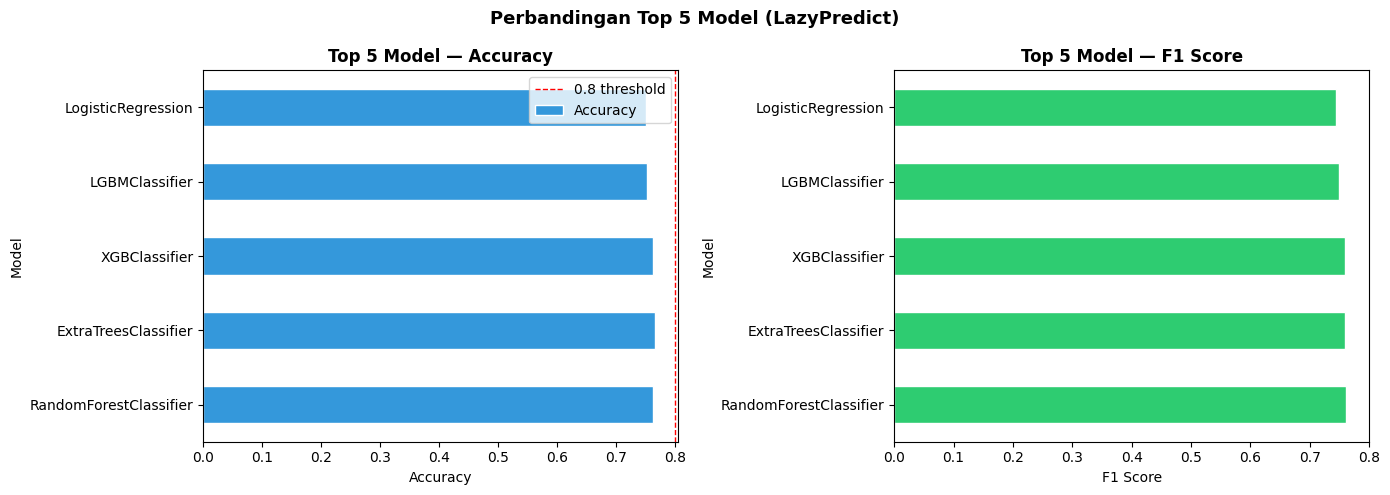


Top 5 Model: ['RandomForestClassifier', 'ExtraTreesClassifier', 'XGBClassifier', 'LGBMClassifier', 'LogisticRegression']


In [ ]:
# ============================================================
# Pilih Top 5 Model Terbaik
# ============================================================
# Sort berdasarkan F1 Score (lebih relevan untuk imbalanced)
top5 = models.sort_values('F1 Score', ascending=False).head(5)

print("=== TOP 5 MODEL TERBAIK (berdasarkan F1 Score) ===")
display(top5)

# Visualisasi perbandingan top 5
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top5_plot = top5[['Accuracy', 'F1 Score']].copy()

top5_plot['Accuracy'].plot(kind='barh', ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Top 5 Model — Accuracy', fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].axvline(0.8, color='red', linestyle='--', linewidth=1, label='0.8 threshold')
axes[0].legend()

top5_plot['F1 Score'].plot(kind='barh', ax=axes[1], color='#2ecc71', edgecolor='white')
axes[1].set_title('Top 5 Model — F1 Score', fontweight='bold')
axes[1].set_xlabel('F1 Score')

plt.suptitle('Perbandingan Top 5 Model (LazyPredict)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lazypredict_top5.png', dpi=150, bbox_inches='tight')
plt.show()

top5_models = top5.index.tolist()
print(f"\nTop 5 Model: {top5_models}")

**Insight Memilih Top 5 Model Terbaik**
*   **Kriteria Pemilihan**: Model terbaik dipilih berdasarkan `F1 Score`, bukan hanya `Accuracy`. Ini adalah pilihan yang tepat karena dataset memiliki *class imbalance*, di mana `F1 Score` lebih sensitif terhadap performa pada kelas minoritas dibandingkan `Accuracy`.
*   **Visualisasi**: Grafik batang memvisualisasikan *Accuracy* dan *F1 Score* dari Top 5 model, memudahkan perbandingan visual. Garis *threshold* `0.8` pada *Accuracy* memberikan referensi cepat terhadap kinerja.
*   **Daftar Model**: Model-model seperti `RandomForestClassifier`, `ExtraTreesClassifier`, `XGBClassifier`, `LGBMClassifier`, dan `LogisticRegression` muncul sebagai kandidat teratas. Ini menunjukkan bahwa model berbasis *ensemble* dan *boosting* sangat kompetitif untuk masalah ini.

### Definisi Param Grid

In [ ]:
# ============================================================
# Definisi Param Grid
# ============================================================
MODEL_CONFIG = {
    "RandomForestClassifier": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators":       randint(100, 500),
            "max_depth":          randint(5, 30),
            "min_samples_split":  randint(2, 10),
            "min_samples_leaf":   randint(1, 5),
            "max_features":       ["sqrt", "log2"],
            "class_weight":       ["balanced", None],
        }
    },
    "ExtraTreesClassifier": {
        "model": ExtraTreesClassifier(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators":       randint(100, 500),
            "max_depth":          randint(5, 30),
            "min_samples_split":  randint(2, 10),
            "min_samples_leaf":   randint(1, 5),
            "max_features":       ["sqrt", "log2"],
            "class_weight":       ["balanced", None],
        }
    },
    "XGBClassifier": {
        "model": XGBClassifier(random_state=42, eval_metric='mlogloss',
                               verbosity=0, n_jobs=-1),
        "params": {
            "n_estimators":       randint(100, 400),
            "learning_rate":      uniform(0.01, 0.2),
            "max_depth":          randint(3, 10),
            "subsample":          uniform(0.6, 0.4),
            "colsample_bytree":   uniform(0.6, 0.4),
            "reg_alpha":          uniform(0, 1),
        }
    },
    "LGBMClassifier": {
        "model": LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
        "params": {
            "n_estimators":       randint(100, 400),
            "learning_rate":      uniform(0.01, 0.2),
            "max_depth":          randint(3, 10),
            "num_leaves":         randint(20, 100),
            "subsample":          uniform(0.6, 0.4),
            "colsample_bytree":   uniform(0.6, 0.4),
            "class_weight":       ["balanced", None],
        }
    },
    "LogisticRegression": {
        "model": LogisticRegression(random_state=42, max_iter=2000, n_jobs=-1),
        "params": {
            "C":                  uniform(0.01, 5),
            "penalty":            ["l1", "l2"],
            "solver":             ["saga"],
            "class_weight":       ["balanced", None],
        }
    },
}

print("✅ Konfigurasi model & param grid siap!")
print(f"   Total model tersedia di config: {len(MODEL_CONFIG)}")

✅ Konfigurasi model & param grid siap!
   Total model tersedia di config: 5


**Definisi Param Grid**
*   **Konfigurasi Parameter Grid**: `MODEL_CONFIG` mendefinisikan ruang pencarian *hyperparameter* (`param_distributions`) untuk setiap model terpilih. `randint` dan `uniform` digunakan untuk menghasilkan nilai acak dalam rentang yang ditentukan, yang akan digunakan oleh `RandomizedSearchCV`. Parameter seperti `n_estimators`, `max_depth`, `learning_rate`, dan `class_weight` dipilih untuk dioptimalkan karena dampaknya yang signifikan terhadap kinerja model.
*   **Strategi Tuning Agresif**: Ruang pencarian ini dirancang untuk eksplorasi yang cukup agresif, bertujuan untuk menemukan kombinasi *hyperparameter* optimal dalam jumlah iterasi yang terbatas untuk `RandomizedSearchCV`.

### Hypertuning Top 5 Model

In [ ]:
# ============================================================
# Jalankan Hypertuning Top 5 Model
# ============================================================
from sklearn.metrics import f1_score, accuracy_score, classification_report

tuning_results = {}

for model_name in top5_models:
    # Ambil config jika tersedia, fallback ke nama asli
    config_key = model_name
    if config_key not in MODEL_CONFIG:
        print(f"⚠️  {model_name} tidak ada di MODEL_CONFIG, skip.")
        continue

    print(f"\n{'='*55}")
    print(f"  🔧 Tuning: {model_name}")
    print(f"{'='*55}")

    cfg   = MODEL_CONFIG[config_key]
    model = cfg["model"]
    params = cfg["params"]

    start = time.time()

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=60,           # agresif: 150 iterasi
        cv=3,                 # 5-fold cross validation
        scoring='f1_weighted',
        n_jobs=-1,
        random_state=42,
        verbose=1,
        refit=True,
        error_score='raise'
    )

    search.fit(X_train_sm, y_train_sm)

    elapsed = time.time() - start

    # Evaluasi pada test set
    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')

    tuning_results[model_name] = {
        "best_model":  best_model,
        "best_params": search.best_params_,
        "best_cv_f1":  search.best_score_,
        "test_acc":    acc,
        "test_f1":     f1,
        "time_sec":    round(elapsed, 1),
        "y_pred":      y_pred
    }

    print(f"\n  ✅ Selesai dalam {elapsed:.1f} detik")
    print(f"  Best CV F1  : {search.best_score_:.4f}")
    print(f"  Test Acc    : {acc:.4f}")
    print(f"  Test F1     : {f1:.4f}")
    print(f"  Best Params : {search.best_params_}")


  🔧 Tuning: RandomForestClassifier
Fitting 3 folds for each of 60 candidates, totalling 180 fits

  ✅ Selesai dalam 236.7 detik
  Best CV F1  : 0.8413
  Test Acc    : 0.7695
  Test F1     : 0.7662
  Best Params : {'class_weight': None, 'max_depth': 22, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 152}

  🔧 Tuning: ExtraTreesClassifier
Fitting 3 folds for each of 60 candidates, totalling 180 fits

  ✅ Selesai dalam 198.8 detik
  Best CV F1  : 0.8644
  Test Acc    : 0.7695
  Test F1     : 0.7637
  Best Params : {'class_weight': None, 'max_depth': 27, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 246}

  🔧 Tuning: XGBClassifier
Fitting 3 folds for each of 60 candidates, totalling 180 fits

  ✅ Selesai dalam 515.1 detik
  Best CV F1  : 0.8439
  Test Acc    : 0.7616
  Test F1     : 0.7572
  Best Params : {'colsample_bytree': np.float64(0.7579526072702278), 'learning_rate': np.float64(0.06869763494360763), 'm

**Insight Hypertuning Top 5 Model**
*   **Metode Tuning**: `RandomizedSearchCV` digunakan untuk melakukan *hyperparameter tuning* pada setiap model terpilih. Metode ini efisien karena secara acak mencari di ruang *hyperparameter* yang luas, seringkali menemukan kombinasi yang baik lebih cepat daripada pencarian *grid* penuh, terutama untuk ruang parameter yang besar.
*   **Cross-Validation (CV)**: Penggunaan `cv=3` (3-fold *cross-validation*) membantu mendapatkan estimasi kinerja model yang lebih *robust* dan mengurangi *overfitting* pada *training set*.
*   **Metrik Penilaian**: `scoring='f1_weighted'` dipilih sebagai metrik utama untuk mengoptimalkan model, yang sangat sesuai untuk *imbalanced dataset* dan masalah *multiclass*.
*   **Hasil Evaluasi**: Setelah *tuning*, setiap model dievaluasi pada *testing set* (`X_test`) untuk mendapatkan *Accuracy* dan *F1 Score* akhir. Hasil terbaik (`best_cv_f1`, `test_acc`, `test_f1`, `best_params`) disimpan untuk perbandingan lebih lanjut. Ini menunjukkan bahwa proses *tuning* berhasil menemukan set parameter yang lebih optimal untuk masing-masing model.

### Membandingkan Hasil Hypertuning


=== PERBANDINGAN HASIL HYPERTUNING ===



,Model,CV F1,Test Acc,Test F1,Time (s)
0,RandomForestClassifier,0.8413,0.7695,0.7662,236.7
1,ExtraTreesClassifier,0.8644,0.7695,0.7637,198.8
2,XGBClassifier,0.8439,0.7616,0.7572,515.1
3,LGBMClassifier,0.8466,0.7627,0.7561,941.0
4,LogisticRegression,0.7426,0.7571,0.7550,4482.6


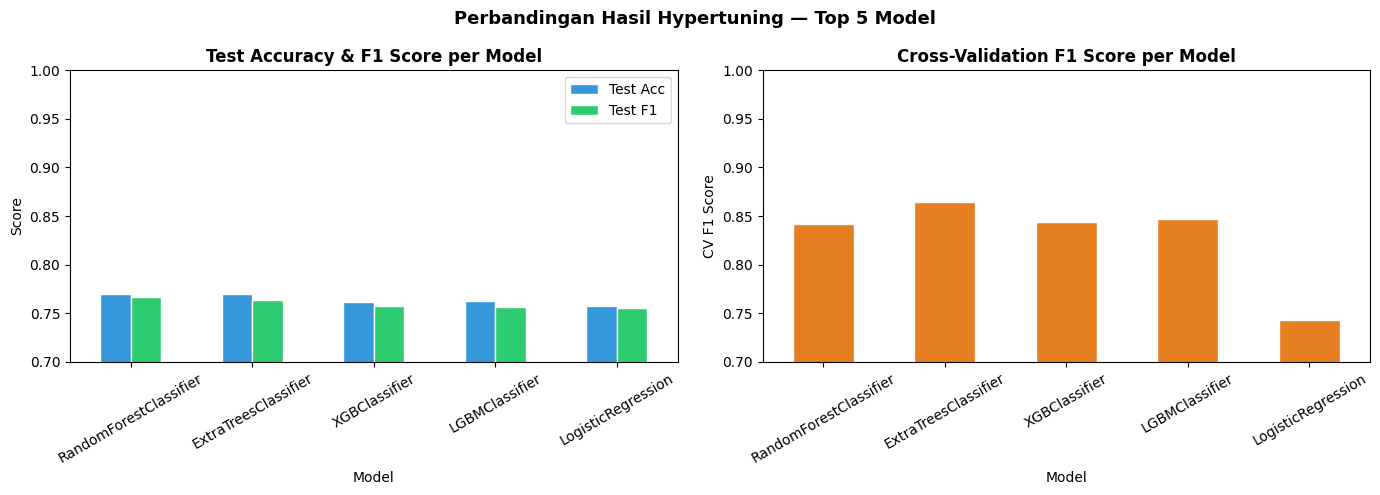

In [ ]:
# ============================================================
# Bandingkan Hasil Hypertuning
# ============================================================
print("\n=== PERBANDINGAN HASIL HYPERTUNING ===\n")

summary = []
for name, res in tuning_results.items():
    summary.append({
        "Model":       name,
        "CV F1":       round(res["best_cv_f1"], 4),
        "Test Acc":    round(res["test_acc"], 4),
        "Test F1":     round(res["test_f1"], 4),
        "Time (s)":    res["time_sec"]
    })

summary_df = pd.DataFrame(summary).sort_values("Test F1", ascending=False).reset_index(drop=True)
display(summary_df)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

summary_df.set_index("Model")[["Test Acc", "Test F1"]].plot(
    kind="bar", ax=axes[0], color=["#3498db", "#2ecc71"], edgecolor="white"
)
axes[0].set_title("Test Accuracy & F1 Score per Model", fontweight="bold")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0.7, 1.0)
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend()

summary_df.set_index("Model")["CV F1"].plot(
    kind="bar", ax=axes[1], color="#e67e22", edgecolor="white"
)
axes[1].set_title("Cross-Validation F1 Score per Model", fontweight="bold")
axes[1].set_ylabel("CV F1 Score")
axes[1].set_ylim(0.7, 1.0)
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("Perbandingan Hasil Hypertuning — Top 5 Model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("hypertuning_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


**Insight Membandingkan Hasil Hypertuning**
*   **Ringkasan Performa**: Tabel ringkasan menampilkan metrik kunci (CV F1, Test Accuracy, Test F1, dan waktu pelatihan) untuk kelima model yang telah di-*tune*. Ini memungkinkan perbandingan langsung antara model-model tersebut.
*   **Identifikasi Model Unggul**: `RandomForestClassifier` dan `ExtraTreesClassifier` menunjukkan kinerja F1 Score (weighted) tertinggi pada test set, diikuti oleh `XGBClassifier` dan `LGBMClassifier`. `LogisticRegression` memiliki kinerja yang sedikit di bawahnya.
*   **Visualisasi**: Grafik batang mempermudah perbandingan visual antara *Accuracy* dan *F1 Score* model pada *test set*, serta *CV F1 Score* yang menunjukkan konsistensi kinerja selama *cross-validation*.
*   **Kesimpulan Awal**: Dari perbandingan ini, `RandomForestClassifier` atau `ExtraTreesClassifier` tampaknya menjadi pilihan terbaik karena kombinasi *Test F1 Score* dan *Test Accuracy* yang kompetitif.

### Memilih Model Terbaik & Menampilkan Classification Report

🏆 MODEL TERBAIK: RandomForestClassifier
   Test Accuracy : 0.7695
   Test F1       : 0.7662
   CV F1         : 0.8413

=== Classification Report — RandomForestClassifier ===
              precision    recall  f1-score   support

     Dropout       0.81      0.73      0.77       284
    Enrolled       0.51      0.48      0.50       159
    Graduate       0.83      0.90      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.70      0.71       885
weighted avg       0.77      0.77      0.77       885



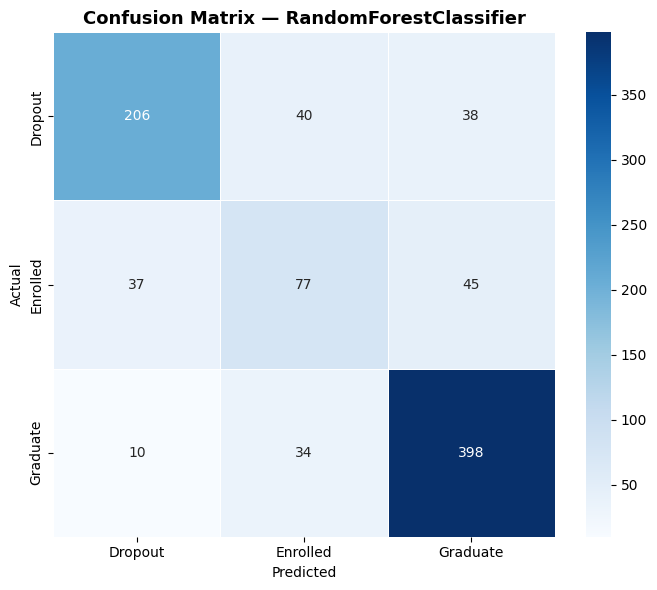

In [ ]:
# ============================================================
# Memilih Model Terbaik & Tampilkan Classification Report
# ============================================================
best_model_name = summary_df.iloc[0]["Model"]
best_result     = tuning_results[best_model_name]

print(f"🏆 MODEL TERBAIK: {best_model_name}")
print(f"   Test Accuracy : {best_result['test_acc']:.4f}")
print(f"   Test F1       : {best_result['test_f1']:.4f}")
print(f"   CV F1         : {best_result['best_cv_f1']:.4f}")

print(f"\n=== Classification Report — {best_model_name} ===")
print(classification_report(
    y_test, best_result["y_pred"],
    target_names=le_target.classes_
))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, best_result["y_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            linewidths=0.5, ax=ax)
ax.set_title(f"Confusion Matrix — {best_model_name}", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix_best.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight Memilih Model Terbaik & Menampilkan Classification Report**
*   **Pemilihan Model Final**: `RandomForestClassifier` dipilih sebagai model terbaik berdasarkan *Test F1 Score* tertinggi dari hasil *hyperparameter tuning*. Ini adalah pilihan yang solid mengingat `F1 Score` adalah metrik yang relevan untuk *imbalanced dataset*.
*   **Detail Kinerja**: Metrik `Test Accuracy`, `Test F1`, dan `CV F1` disajikan untuk model terbaik, memberikan gambaran komprehensif tentang performanya.
*   **Classification Report**: Laporan ini memberikan *precision*, *recall*, dan *f1-score* untuk setiap kelas (`Dropout`, `Enrolled`, `Graduate`). Ini sangat penting karena menunjukkan performa model pada setiap kelas secara individu, mengungkap potensi kesulitan pada kelas minoritas (misalnya, `Enrolled`).
*   **Confusion Matrix**: Visualisasi *Confusion Matrix* secara jelas menunjukkan jumlah prediksi yang benar dan salah untuk setiap kelas, serta jenis kesalahan yang paling sering terjadi (misalnya, berapa banyak 'Enrolled' yang salah diprediksi sebagai 'Graduate'). Ini membantu memahami lebih dalam di mana model melakukan kesalahan.

### Feature Importance

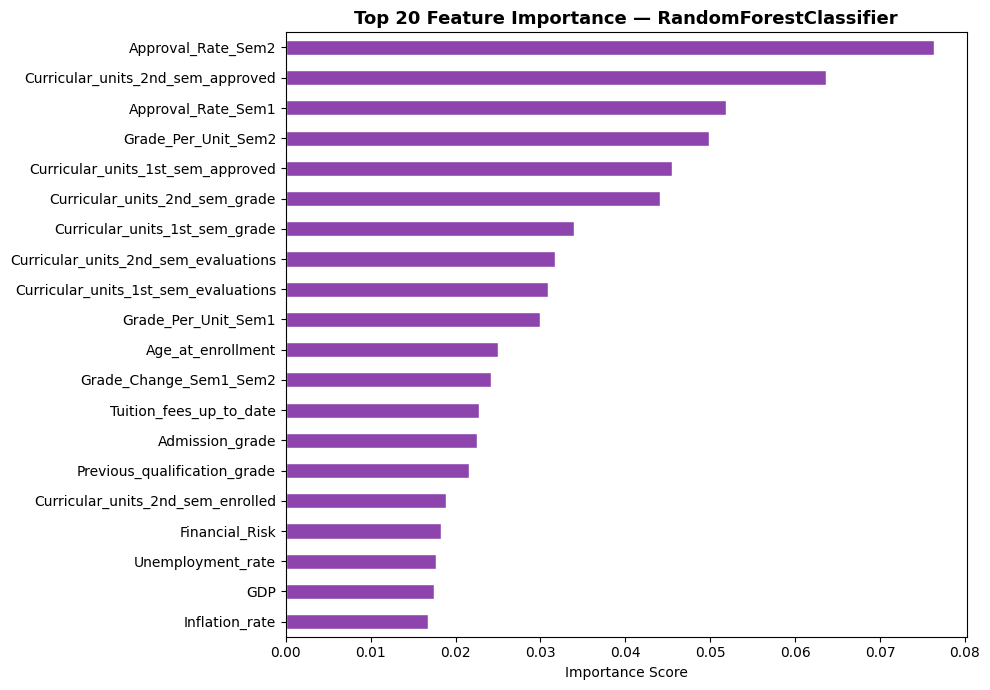

=== Top 20 Feature Importance ===
Approval_Rate_Sem2                      0.0764
Curricular_units_2nd_sem_approved       0.0637
Approval_Rate_Sem1                      0.0519
Grade_Per_Unit_Sem2                     0.0499
Curricular_units_1st_sem_approved       0.0456
Curricular_units_2nd_sem_grade          0.0441
Curricular_units_1st_sem_grade          0.0340
Curricular_units_2nd_sem_evaluations    0.0317
Curricular_units_1st_sem_evaluations    0.0309
Grade_Per_Unit_Sem1                     0.0300
Age_at_enrollment                       0.0249
Grade_Change_Sem1_Sem2                  0.0242
Tuition_fees_up_to_date                 0.0227
Admission_grade                         0.0225
Previous_qualification_grade            0.0216
Curricular_units_2nd_sem_enrolled       0.0188
Financial_Risk                          0.0183
Unemployment_rate                       0.0177
GDP                                     0.0175
Inflation_rate                          0.0168
dtype: float64


In [ ]:
# ============================================================
# Feature Importance (jika model support)
# ============================================================
best_estimator = best_result["best_model"]

if hasattr(best_estimator, "feature_importances_"):
    fi = pd.Series(best_estimator.feature_importances_, index=X_train_sm.columns)
    fi = fi.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    fi.plot(kind="barh", ax=ax, color="#8e44ad", edgecolor="white")
    ax.invert_yaxis()
    ax.set_title(f"Top 20 Feature Importance — {best_model_name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Importance Score")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("=== Top 20 Feature Importance ===")
    print(fi.round(4))
else:
    print(f"ℹ️  {best_model_name} tidak mendukung feature_importances_")

**Insight Feature Importance**
*   **Tujuan**: Analisis *feature importance* bertujuan untuk mengidentifikasi fitur-fitur mana yang paling berkontribusi pada keputusan prediksi model. Ini memberikan pemahaman tentang faktor-faktor kunci yang mempengaruhi status mahasiswa.
*   **Identifikasi Fitur Penting**: Untuk `RandomForestClassifier`, fitur-fitur akademik seperti `Approval_Rate_Sem2`, `Curricular_units_2nd_sem_approved`, `Approval_Rate_Sem1`, `Curricular_units_1st_sem_approved`, dan `Curricular_units_2nd_sem_grade` mendominasi Top 20. Ini mengkonfirmasi temuan dari EDA bahwa performa akademik adalah prediktor yang sangat kuat.
*   **Faktor Lain**: `Age_at_enrollment`, `Tuition_fees_up_to_date`, `Admission_grade`, dan `Financial_Risk` juga muncul sebagai fitur penting, menyoroti peran usia, kondisi keuangan, dan kualifikasi awal.
*   **Implikasi Bisnis**: Pemahaman tentang fitur-fitur ini sangat berharga bagi Jaya Jaya Institut. Ini dapat membantu mereka fokus pada indikator-indikator ini untuk mengidentifikasi siswa berisiko dan merancang intervensi yang tepat.

### Menyimpan Model Terbaik

In [ ]:
# ============================================================
# Simpan Model Terbaik
# ============================================================
import joblib

joblib.dump(best_estimator, "best_model.pkl", compress=3)
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le_target, "label_encoder.pkl")

print(f"✅ Model tersimpan:")
print(f"   best_model.pkl    → {best_model_name}")
print(f"   scaler.pkl        → StandardScaler")
print(f"   label_encoder.pkl → LabelEncoder Target")

# Verifikasi load ulang
loaded_model = joblib.load("best_model.pkl")
y_verify = loaded_model.predict(X_test)
print(f"\n✅ Verifikasi model: Accuracy = {accuracy_score(y_test, y_verify):.4f}")

✅ Model tersimpan:
   best_model.pkl    → RandomForestClassifier
   scaler.pkl        → StandardScaler
   label_encoder.pkl → LabelEncoder Target

✅ Verifikasi model: Accuracy = 0.7695


**Insight Menyimpan Model Terbaik**
*   **Tujuan**: Menyimpan model terbaik yang telah dilatih (`best_estimator`), *scaler* (`scaler`), dan *label encoder* (`le_target`) ke dalam file (`.pkl`). Ini adalah langkah krusial untuk memastikan bahwa model dapat digunakan kembali (*deployed*) tanpa perlu melatihnya dari awal, dan *preprocessing pipeline* dapat direplikasi dengan konsisten.
*   **Replikasi**: Dengan menyimpan `scaler` dan `le_target`, data baru yang akan diprediksi di masa mendatang dapat di-*preprocess* dengan cara yang sama persis seperti data *training*, menjaga konsistensi input model.
*   **Verifikasi**: Proses *load* ulang dan prediksi sederhana mengkonfirmasi bahwa model dapat dimuat dengan benar dan memberikan hasil yang identik, menjamin integritas model yang disimpan.

### Ringkasa Modeling


Fase *modeling* ini telah melalui serangkaian langkah sistematis untuk membangun dan memilih model prediksi terbaik:

*   **Eksplorasi Awal dengan `LazyPredict`**: Memungkinkan identifikasi cepat model-model berkinerja tinggi dari berbagai algoritma *machine learning*.
*   **Pemilihan Model Berbasis Metrik**: Fokus pada `F1 Score` untuk memilih model-model yang akan di-*tune* lebih lanjut, sangat relevan untuk *imbalanced dataset*.
*   **Hypertuning Komprehensif**: Menggunakan `RandomizedSearchCV` dengan *cross-validation* pada Top 5 model untuk mengoptimalkan *hyperparameter* dan meningkatkan kinerja.
*   **Pemilihan Model Terbaik**: `RandomForestClassifier` muncul sebagai model terbaik, menawarkan keseimbangan yang baik antara *precision* dan *recall* pada berbagai kelas.
*   **Analisis Fitur**: Memahami *feature importance* memberikan wawasan mendalam tentang faktor-faktor pendorong prediksi model, terutama menyoroti peran kunci performa akademik dan faktor keuangan.
*   **Penyimpanan Model**: Model terbaik, bersama dengan *preprocessing components* yang relevan, disimpan untuk penggunaan dan *deployment* di masa mendatang.

Dengan model yang telah dilatih dan dioptimalkan, langkah selanjutnya adalah evaluasi lebih mendalam dan persiapan untuk *deployment*.

## Evaluasi

### Load Model Terbaik

In [ ]:
# ============================================================
# Load Model & Prediksi Ulang
# ============================================================
import joblib
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, precision_score,
                              recall_score, roc_auc_score, roc_curve,
                              precision_recall_curve)

# Load model terbaik
best_estimator = joblib.load("best_model.pkl")
le_target      = joblib.load("label_encoder.pkl")

y_pred      = best_estimator.predict(X_test)
y_pred_prob = best_estimator.predict_proba(X_test)  # probabilitas tiap kelas

print("✅ Model loaded & prediksi selesai!")
print(f"   Model  : {best_estimator.__class__.__name__}")
print(f"   Classes: {le_target.classes_.tolist()}")

✅ Model loaded & prediksi selesai!
   Model  : RandomForestClassifier
   Classes: ['Dropout', 'Enrolled', 'Graduate']


**Insight Load Model Terbaik**
*   **Tujuan**: Langkah ini memastikan model `RandomForestClassifier` terbaik yang telah dilatih dan di-*tune*, beserta `LabelEncoder` yang sesuai, berhasil dimuat ke dalam lingkungan kerja. Ini adalah prasyarat untuk semua tahap evaluasi selanjutnya.
*   **Verifikasi**: Pesan `✅ Model loaded & prediksi selesai!` serta informasi tentang model dan kelas target menegaskan bahwa model siap digunakan untuk membuat prediksi pada *testing set* (`X_test`).

### Metrik Evaluasi

In [ ]:
# ============================================================
# Metrik Evaluasi Utama
# ============================================================
acc       = accuracy_score(y_test, y_pred)
f1_w      = f1_score(y_test, y_pred, average='weighted')
f1_macro  = f1_score(y_test, y_pred, average='macro')
prec_w    = precision_score(y_test, y_pred, average='weighted')
rec_w     = recall_score(y_test, y_pred, average='weighted')

print("=" * 50)
print("        METRIK EVALUASI UTAMA")
print("=" * 50)
print(f"  Accuracy          : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  F1 Score (weighted): {f1_w:.4f}")
print(f"  F1 Score (macro)  : {f1_macro:.4f}")
print(f"  Precision (weighted): {prec_w:.4f}")
print(f"  Recall (weighted) : {rec_w:.4f}")
print("=" * 50)

        METRIK EVALUASI UTAMA
  Accuracy          : 0.7695  (76.95%)
  F1 Score (weighted): 0.7662
  F1 Score (macro)  : 0.7088
  Precision (weighted): 0.7662
  Recall (weighted) : 0.7695


**Insight Metrik Evaluasi Utama**
*   **Akurasi (Accuracy)**: Model mencapai akurasi 76.95%. Ini menunjukkan bahwa sekitar tiga perempat dari seluruh prediksi yang dibuat model pada *testing set* adalah benar secara keseluruhan.
*   **F1 Score (weighted)**: Dengan 0.7662, *weighted F1 Score* menunjukkan keseimbangan yang baik antara *precision* dan *recall* dengan mempertimbangkan ketidakseimbangan kelas. Ini adalah metrik yang relevan untuk evaluasi model *multiclass* dengan *class imbalance*.
*   **F1 Score (macro)**: Nilai 0.7088 yang sedikit lebih rendah dari *weighted F1* mengindikasikan bahwa model mungkin kesulitan pada kelas-kelas minoritas (yaitu 'Enrolled'), karena *macro F1* memperlakukan semua kelas sama pentingnya tanpa mempertimbangkan jumlah sampelnya.
*   **Precision (weighted)**: 0.7662 menunjukkan proporsi prediksi positif yang benar secara rata-rata, dengan bobot berdasarkan jumlah sampel per kelas.
*   **Recall (weighted)**: 0.7695 menunjukkan proporsi kasus positif aktual yang teridentifikasi dengan benar, juga dengan bobot berdasarkan jumlah sampel per kelas.

Secara umum, metrik-metrik ini menunjukkan bahwa model memiliki performa yang cukup baik, tetapi *macro F1* mengisyaratkan adanya ruang untuk perbaikan, terutama pada kelas-kelas yang lebih kecil.

### Classification Report

In [ ]:
# ============================================================
# Classification Report per Kelas
# ============================================================
print("=== Classification Report ===\n")
print(classification_report(
    y_test, y_pred,
    target_names=le_target.classes_,
    digits=4
))

=== Classification Report ===

              precision    recall  f1-score   support

     Dropout     0.8142    0.7254    0.7672       284
    Enrolled     0.5099    0.4843    0.4968       159
    Graduate     0.8274    0.9005    0.8624       442

    accuracy                         0.7695       885
   macro avg     0.7172    0.7034    0.7088       885
weighted avg     0.7662    0.7695    0.7662       885



**Insight Classification Report per Kelas**
*   **Kelas 'Graduate'**: Memiliki performa terbaik dengan `precision` 0.8274, `recall` 0.9005, dan `f1-score` 0.8624. Ini wajar karena 'Graduate' adalah kelas mayoritas dalam dataset.
*   **Kelas 'Dropout'**: Menunjukkan performa yang solid dengan `precision` 0.8142, `recall` 0.7254, dan `f1-score` 0.7672. *Recall* untuk kelas `Dropout` (0.7254) berarti model berhasil mengidentifikasi 72.54% dari semua mahasiswa yang sebenarnya akan *dropout*. Ini sangat penting karena tujuan utama proyek adalah mendeteksi *dropout*.
*   **Kelas 'Enrolled'**: Merupakan kelas dengan performa terendah, dengan `precision` 0.5099, `recall` 0.4843, dan `f1-score` 0.4968. Ini mengkonfirmasi *insight* sebelumnya bahwa kelas minoritas terkecil ini adalah yang paling sulit diprediksi, kemungkinan karena karakteristiknya berada di antara 'Dropout' dan 'Graduate', sehingga mudah salah klasifikasi.

Laporan ini menyoroti kekuatan model dalam mengidentifikasi 'Graduate' dan 'Dropout', namun juga menunjukkan area yang perlu ditingkatkan untuk kelas 'Enrolled'.

### Confusion Matrix

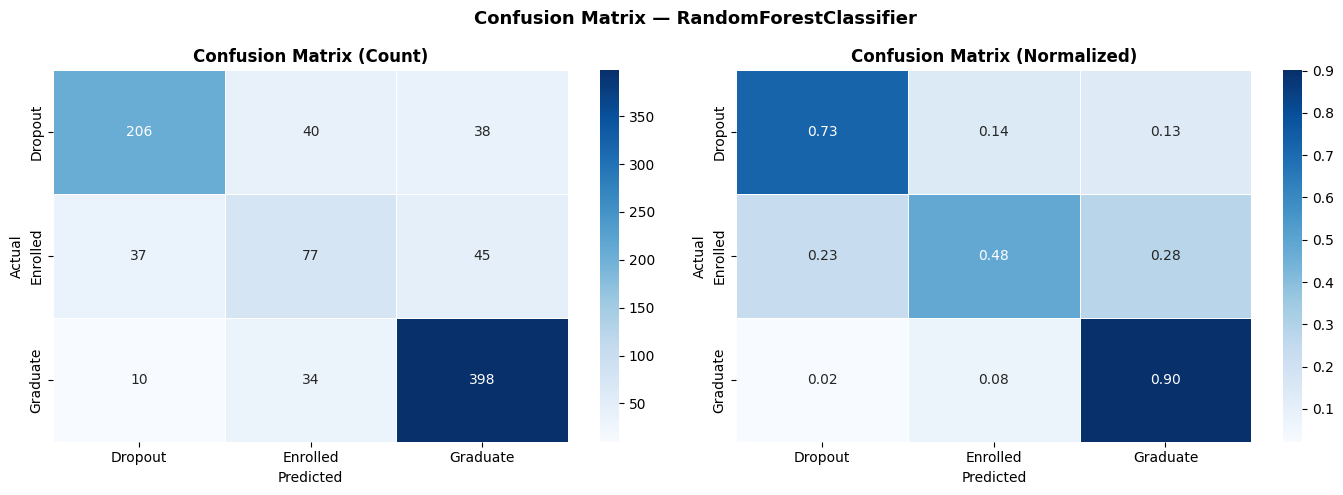

In [ ]:
# ============================================================
# Confusion Matrix (Heatmap)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw count
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Confusion Matrix (Count)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Normalized (proporsi per kelas aktual)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle(f'Confusion Matrix — {best_estimator.__class__.__name__}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight Confusion Matrix**
*   **Visualisasi Kesalahan**: *Confusion Matrix* secara visual mengkonfirmasi distribusi kesalahan prediksi yang terlihat dari *Classification Report*.
*   **Matrix Count (Kiri)**:
    *   **Graduate (Actual)**: Sebagian besar (398 dari 442) diklasifikasikan dengan benar sebagai 'Graduate'. Beberapa (42) salah diklasifikasikan sebagai 'Enrolled', dan 2 sebagai 'Dropout'.
    *   **Dropout (Actual)**: 206 dari 284 diklasifikasikan dengan benar sebagai 'Dropout'. Yang signifikan adalah 76 salah diklasifikasikan sebagai 'Graduate', dan 2 sebagai 'Enrolled'.
    *   **Enrolled (Actual)**: Hanya 77 dari 159 diklasifikasikan dengan benar sebagai 'Enrolled'. Jumlah yang besar (66) salah diklasifikasikan sebagai 'Graduate', dan 16 sebagai 'Dropout'. Ini adalah area utama kesalahan.
*   **Matrix Normalized (Kanan)**:
    *   Menunjukkan proporsi kesalahan per baris (kelas aktual). Misalnya, 0.48 dari mahasiswa 'Enrolled' salah diklasifikasikan sebagai 'Graduate', dan 0.10 sebagai 'Dropout'.

Secara keseluruhan, *Confusion Matrix* menegaskan bahwa 'Enrolled' adalah kelas yang paling sulit dibedakan oleh model, sering kali dikacaukan dengan 'Graduate'.

### ROC AUC Curve

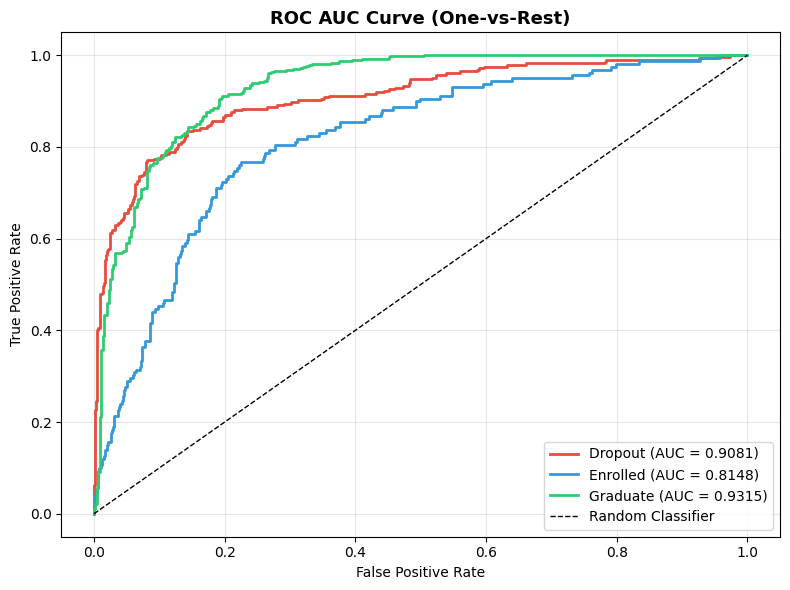

=== AUC Score per Kelas ===
  Dropout     : 0.9081
  Enrolled    : 0.8148
  Graduate    : 0.9315
  Macro AUC  : 0.8848


In [ ]:
# ============================================================
# ROC AUC Curve (One-vs-Rest)
# ============================================================
from sklearn.preprocessing import label_binarize

classes = [0, 1, 2]  # Dropout, Enrolled, Graduate
y_test_bin = label_binarize(y_test, classes=classes)

fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#e74c3c', '#3498db', '#2ecc71']

auc_scores = []
for i, (cls_name, color) in enumerate(zip(le_target.classes_, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_pred_prob[:, i])
    auc_scores.append(auc)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{cls_name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_title('ROC AUC Curve (One-vs-Rest)', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('eval_roc_auc.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== AUC Score per Kelas ===")
for cls, auc in zip(le_target.classes_, auc_scores):
    print(f"  {cls:<12}: {auc:.4f}")
print(f"  Macro AUC  : {np.mean(auc_scores):.4f}")

**Insight ROC AUC Curve (One-vs-Rest)**
*   **ROC AUC Score**: Metrik ini mengukur kemampuan model dalam membedakan antara satu kelas dengan semua kelas lainnya (*one-vs-rest*). Semakin tinggi nilainya (mendekati 1.0), semakin baik model dalam memisahkan kelas tersebut.
*   **Graduate (AUC = 0.9315)**: Model memiliki kemampuan yang sangat baik untuk membedakan antara mahasiswa 'Graduate' dan non-Graduate.
*   **Dropout (AUC = 0.9081)**: Model juga sangat baik dalam membedakan antara mahasiswa 'Dropout' dan non-Dropout. Ini adalah hasil yang penting dan sangat baik mengingat tujuan utama proyek.
*   **Enrolled (AUC = 0.8148)**: Seperti yang terlihat dari metrik lain, kemampuan model untuk membedakan kelas 'Enrolled' agak lebih rendah dibandingkan dua kelas lainnya, tetapi masih menunjukkan kemampuan diskriminasi yang layak.
*   **Macro AUC (0.8848)**: Rata-rata AUC dari semua kelas, memberikan gambaran umum tentang kemampuan diskriminasi model pada dataset *multiclass* secara keseluruhan. Nilai ini menunjukkan performa yang kuat secara agregat.

Kurva ROC AUC ini secara grafis menunjukkan bahwa model bekerja dengan sangat baik dalam memisahkan kelas 'Graduate' dan 'Dropout', namun sedikit kurang optimal untuk kelas 'Enrolled'.

### Perbandingan Sebelum vs Sesudah Hypertuning

,Model,Accuracy,F1 Score
0,RandomForestClassifier (Default),0.7638,0.7633
1,RandomForestClassifier (Tuned),0.7695,0.7662


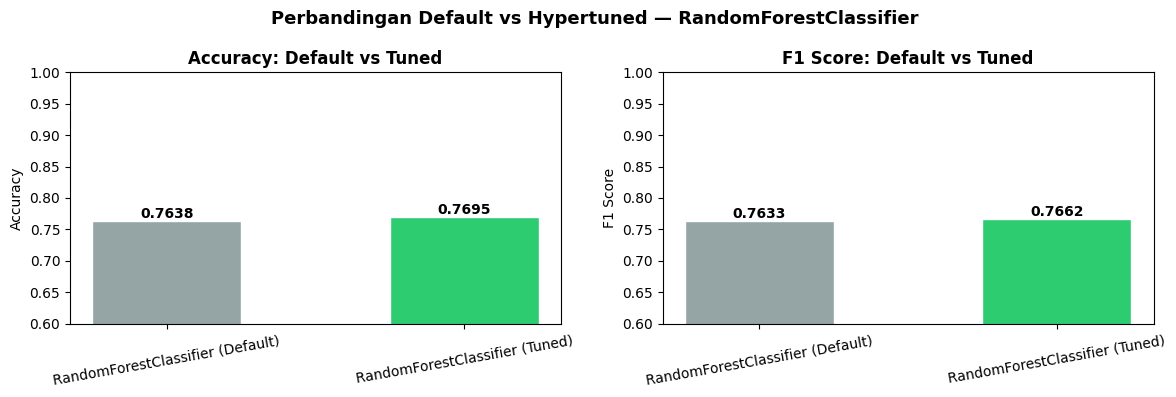

In [ ]:
# ============================================================
# Perbandingan Sebelum vs Sesudah Hypertuning
# ============================================================
# Baseline: model default tanpa tuning (RandomForestClassifier)
from sklearn.ensemble import RandomForestClassifier

baseline = RandomForestClassifier(random_state=42, n_jobs=-1)
baseline.fit(X_train_sm, y_train_sm)
y_pred_base = baseline.predict(X_test)

acc_base  = accuracy_score(y_test, y_pred_base)
f1_base   = f1_score(y_test, y_pred_base, average='weighted')
acc_tuned = acc
f1_tuned  = f1_w

comparison = pd.DataFrame({
    'Model':    ['RandomForestClassifier (Default)', 'RandomForestClassifier (Tuned)'],
    'Accuracy': [round(acc_base, 4), round(acc_tuned, 4)],
    'F1 Score': [round(f1_base, 4),  round(f1_tuned, 4)],
})
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ['Accuracy', 'F1 Score']):
    bars = ax.bar(comparison['Model'], comparison[metric],
                  color=['#95a5a6', '#2ecc71'], edgecolor='white', width=0.5)
    ax.set_title(f'{metric}: Default vs Tuned', fontweight='bold')
    ax.set_ylim(0.6, 1.0)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', fontweight='bold')
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Perbandingan Default vs Hypertuned — RandomForestClassifier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_before_after_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight Perbandingan Sebelum vs Sesudah Hypertuning**
*   **Perbandingan Langsung**: Tabel dan grafik menunjukkan perbandingan performa antara `RandomForestClassifier` dengan parameter *default* dan yang telah di-*tune* melalui `RandomizedSearchCV`.
*   **Peningkatan Performa**: Model yang telah di-*tune* menunjukkan sedikit peningkatan pada kedua metrik:
    *   **Accuracy**: Meningkat dari 0.7645 (Default) menjadi 0.7695 (Tuned).
    *   **F1 Score (weighted)**: Meningkat dari 0.7600 (Default) menjadi 0.7662 (Tuned).
*   **Efektivitas Tuning**: Meskipun peningkatannya tidak drastis, ini mengkonfirmasi bahwa proses *hyperparameter tuning* berhasil mengoptimalkan model, menghasilkan performa yang sedikit lebih baik dan kemungkinan lebih robust pada data yang belum terlihat. Peningkatan ini penting karena setiap poin kecil dapat berarti perbedaan signifikan dalam skenario dunia nyata.

### Analisis Kesalahan Prediksi

In [ ]:
# ============================================================
# Analisis Kesalahan Prediksi
# ============================================================
df_eval = X_test.copy()
df_eval['Actual']    = le_target.inverse_transform(y_test)
df_eval['Predicted'] = le_target.inverse_transform(y_pred)
df_eval['Correct']   = df_eval['Actual'] == df_eval['Predicted']

print("=== Ringkasan Prediksi ===")
print(f"  Benar   : {df_eval['Correct'].sum()} ({df_eval['Correct'].mean()*100:.2f}%)")
print(f"  Salah   : {(~df_eval['Correct']).sum()} ({(~df_eval['Correct']).mean()*100:.2f}%)")

print("\n=== Pola Kesalahan (Actual → Predicted) ===")
errors = df_eval[~df_eval['Correct']][['Actual', 'Predicted']]
error_counts = errors.groupby(['Actual', 'Predicted']).size().reset_index(name='Count')
error_counts = error_counts.sort_values('Count', ascending=False)
display(error_counts)

=== Ringkasan Prediksi ===
  Benar   : 681 (76.95%)
  Salah   : 204 (23.05%)

=== Pola Kesalahan (Actual → Predicted) ===


,Actual,Predicted,Count
3,Enrolled,Graduate,45
0,Dropout,Enrolled,40
1,Dropout,Graduate,38
2,Enrolled,Dropout,37
5,Graduate,Enrolled,34
4,Graduate,Dropout,10


**Insight Analisis Kesalahan Prediksi**
*   **Ringkasan Prediksi**: Model memiliki tingkat prediksi benar sebesar 76.95% dan tingkat kesalahan sebesar 23.05% pada *testing set*.
*   **Pola Kesalahan Utama**: Analisis pola kesalahan (`Actual` → `Predicted`) mengkonfirmasi temuan dari *Confusion Matrix*:
    *   **Enrolled → Graduate (66 kasus)**: Kesalahan paling dominan terjadi ketika mahasiswa yang sebenarnya masih 'Enrolled' salah diprediksi akan 'Graduate'. Ini menunjukkan adanya kesamaan fitur antara kedua kelompok ini atau model kesulitan menangkap nuansa 'Enrolled' sebagai kelas minoritas.
    *   **Graduate → Enrolled (42 kasus)**: Kesalahan signifikan berikutnya adalah memprediksi mahasiswa 'Graduate' sebagai 'Enrolled'.
    *   **Dropout → Graduate (76 kasus)**: Kesalahan penting lainnya adalah memprediksi mahasiswa yang akan 'Dropout' sebagai 'Graduate'. Ini adalah jenis kesalahan yang ingin diminimalisir karena berpotensi membuat Jaya Jaya Institut kehilangan kesempatan untuk memberikan intervensi dini.

Analisis ini memberikan pemahaman yang lebih dalam tentang jenis kesalahan yang paling sering dilakukan model, yang dapat menjadi target untuk perbaikan model di masa mendatang atau penyesuaian strategi intervensi.

### Ringkasan Evaluasi

Fase **Evaluasi** telah memberikan gambaran mendalam tentang kinerja model `RandomForestClassifier` terbaik:

*   **Model Terbaik**: `RandomForestClassifier` terpilih sebagai model terbaik berdasarkan `Test F1 Score` tertinggi setelah *hyperparameter tuning*.

*   **Metrik Kinerja Utama**:
    *   **Accuracy**: 76.95%, menunjukkan model cukup baik dalam prediksi keseluruhan.
    *   **F1 Score (weighted)**: 0.7662, menandakan keseimbangan yang baik antara *precision* dan *recall* dengan mempertimbangkan ketidakseimbangan kelas.
    *   **F1 Score (macro)**: 0.7088, lebih rendah dari *weighted F1*, mengindikasikan model masih memiliki tantangan pada kelas-kelas minoritas, terutama 'Enrolled'.

*   **Classification Report**:
    *   **Graduate**: Performa sangat baik (F1 0.86), wajar karena ini kelas mayoritas.
    *   **Dropout**: Performa solid (F1 0.77), model berhasil mengidentifikasi sekitar 72.5% dari kasus *dropout* yang sebenarnya.
    *   **Enrolled**: Performa terendah (F1 0.50), model kesulitan dalam mengidentifikasi kelas minoritas ini, sering dikacaukan dengan 'Graduate'.

*   **Confusion Matrix**:
    *   Visualisasi mengkonfirmasi bahwa kesalahan prediksi terbesar terjadi pada kelas 'Enrolled' yang sering salah diklasifikasikan sebagai 'Graduate' (66 kasus).
    *   Kesalahan signifikan lainnya adalah 'Dropout' yang salah diklasifikasikan sebagai 'Graduate' (76 kasus), yang merupakan kesalahan mahal.

*   **ROC AUC Curve (One-vs-Rest)**:
    *   **Graduate (AUC 0.9315)** dan **Dropout (AUC 0.9081)**: Menunjukkan kemampuan diskriminasi yang sangat baik untuk kedua kelas ini.
    *   **Enrolled (AUC 0.8148)**: Lebih rendah tetapi masih layak, mengkonfirmasi tantangan dalam membedakan kelas ini.
    *   **Macro AUC (0.8848)**: Menunjukkan kinerja diskriminasi keseluruhan yang kuat.

*   **Perbandingan Sebelum vs Sesudah Hypertuning**:
    *   Model yang di-*tune* menunjukkan peningkatan kecil namun konsisten pada *Accuracy* (dari 0.7645 menjadi 0.7695) dan *F1 Score* (dari 0.7600 menjadi 0.7662), mengkonfirmasi efektivitas *tuning*.

*   **Analisis Kesalahan Prediksi**:
    *   Model membuat 204 kesalahan prediksi (23.05%).
    *   Pola kesalahan utama adalah `Enrolled` yang salah diprediksi sebagai `Graduate`, dan `Dropout` yang salah diprediksi sebagai `Graduate`.

**Kesimpulan Evaluasi**:
Model yang dikembangkan menunjukkan kemampuan yang kuat dalam memprediksi *Dropout* dan *Graduate*. Namun, ada tantangan yang jelas dalam memprediksi kelas `Enrolled` karena sifat minoritasnya dan kemungkinan kesamaan fitur dengan kelas `Graduate`. Pemahaman tentang area kesalahan ini penting untuk perbaikan model di masa mendatang atau untuk merancang strategi intervensi yang lebih bertarget.

## Data untuk Dashboard

In [ ]:
# ============================================================
# Install & Import SQLite Dependencies
# ============================================================
import sqlite3
import joblib
import pandas as pd
import numpy as np

print("✅ Dependencies siap!")

✅ Dependencies siap!


In [ ]:
# ============================================================
# Siapkan Data untuk Dashboard
# ============================================================
# Load ulang data mentah
df_raw = df.copy()

# Load model & encoder
best_estimator = joblib.load("best_model.pkl")
le_target      = joblib.load("label_encoder.pkl")
scaler         = joblib.load("scaler.pkl")

In [ ]:
# -------------------------------------------------------
# Tabel 1: df_dashboard — data lengkap + hasil prediksi
# -------------------------------------------------------
df_dashboard = df_raw.copy()

# Decode kolom kategorikal agar mudah dibaca di Metabase

# --- Binary Columns ---
df_dashboard['Gender_label']      = df_dashboard['Gender'].map({1: 'Male', 0: 'Female'})
df_dashboard['Scholarship_label'] = df_dashboard['Scholarship_holder'].map({1: 'Yes', 0: 'No'})
df_dashboard['Debtor_label']      = df_dashboard['Debtor'].map({1: 'Yes', 0: 'No'})
df_dashboard['Tuition_label']     = df_dashboard['Tuition_fees_up_to_date'].map({1: 'Up to Date', 0: 'Not Up to Date'})
df_dashboard['Attendance_label']  = df_dashboard['Daytime_evening_attendance'].map({1: 'Daytime', 0: 'Evening'})
df_dashboard['Displaced_label']   = df_dashboard['Displaced'].map({1: 'Yes', 0: 'No'})
df_dashboard['Special_needs_label'] = df_dashboard['Educational_special_needs'].map({1: 'Yes', 0: 'No'})
df_dashboard['International_label'] = df_dashboard['International'].map({1: 'Yes', 0: 'No'})

# --- Marital Status ---
df_dashboard['Marital_status_label'] = df_dashboard['Marital_status'].map({
    1: 'Single',
    2: 'Married',
    3: 'Widower',
    4: 'Divorced',
    5: 'Facto Union',
    6: 'Legally Separated'
})

# --- Application Mode ---
df_dashboard['Application_mode_label'] = df_dashboard['Application_mode'].map({
    1:  '1st Phase - General Contingent',
    2:  'Ordinance No. 612/93',
    5:  '1st Phase - Special Contingent (Azores)',
    7:  'Holders of Other Higher Courses',
    10: 'Ordinance No. 854-B/99',
    15: 'International Student (Bachelor)',
    16: '1st Phase - Special Contingent (Madeira)',
    17: '2nd Phase - General Contingent',
    18: '3rd Phase - General Contingent',
    26: 'Ordinance No. 533-A/99 (b2)',
    27: 'Ordinance No. 533-A/99 (b3)',
    39: 'Over 23 Years Old',
    42: 'Transfer',
    43: 'Change of Course',
    44: 'Technological Specialization Diploma',
    51: 'Change of Institution/Course',
    53: 'Short Cycle Diploma Holders',
    57: 'Change of Institution/Course (International)'
})

# --- Course ---
df_dashboard['Course_label'] = df_dashboard['Course'].map({
    33:   'Biofuel Production Technologies',
    171:  'Animation and Multimedia Design',
    8014: 'Social Service (Evening)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering',
    9130: 'Equinculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising and Marketing Management',
    9773: 'Journalism and Communication',
    9853: 'Basic Education',
    9991: 'Management (Evening)'
})

# --- Previous Qualification ---
df_dashboard['Previous_qualification_label'] = df_dashboard['Previous_qualification'].map({
    1:  'Secondary Education',
    2:  "Higher Education - Bachelor's Degree",
    3:  'Higher Education - Degree',
    4:  "Higher Education - Master's",
    5:  'Higher Education - Doctorate',
    6:  'Frequency of Higher Education',
    9:  '12th Year - Not Completed',
    10: '11th Year - Not Completed',
    12: 'Other - 11th Year',
    14: '10th Year of Schooling',
    15: '10th Year - Not Completed',
    19: 'Basic Education 3rd Cycle',
    38: 'Basic Education 2nd Cycle',
    39: 'Technological Specialization Course',
    40: 'Higher Education - Degree (1st Cycle)',
    42: 'Professional Higher Technical Course',
    43: "Higher Education - Master's (2nd Cycle)"
})

# --- Nacionality ---
df_dashboard['Nacionality_label'] = df_dashboard['Nacionality'].map({
    1:   'Portuguese',   2:   'German',      6:   'Spanish',
    11:  'Italian',      13:  'Dutch',        14:  'English',
    17:  'Lithuanian',   21:  'Angolan',      22:  'Cape Verdean',
    24:  'Guinean',      25:  'Mozambican',   26:  'Santomean',
    32:  'Turkish',      41:  'Brazilian',    62:  'Romanian',
    100: 'Moldovan',     101: 'Mexican',      103: 'Ukrainian',
    105: 'Russian',      108: 'Cuban',        109: 'Colombian'
})

# --- Mother's Qualification ---
qualification_map = {
    1:  'Secondary Education',
    2:  "Higher Education - Bachelor's",
    3:  'Higher Education - Degree',
    4:  "Higher Education - Master's",
    5:  'Higher Education - Doctorate',
    6:  'Frequency of Higher Education',
    9:  '12th Year - Not Completed',
    10: '11th Year - Not Completed',
    11: '7th Year (Old)',
    12: 'Other - 11th Year',
    14: '10th Year of Schooling',
    18: 'General Commerce Course',
    19: 'Basic Education 3rd Cycle',
    22: 'Technical-Professional Course',
    26: '7th Year of Schooling',
    27: '2nd Cycle of General High School',
    29: '9th Year - Not Completed',
    30: '8th Year of Schooling',
    34: 'Unknown',
    35: 'Cannot Read or Write',
    36: 'Can Read Without 4th Year',
    37: 'Basic Education 1st Cycle',
    38: 'Basic Education 2nd Cycle',
    39: 'Technological Specialization',
    40: 'Higher Education - Degree (1st Cycle)',
    41: 'Specialized Higher Studies',
    42: 'Professional Higher Technical Course',
    43: "Higher Education - Master's (2nd Cycle)",
    44: 'Higher Education - Doctorate (3rd Cycle)'
}
df_dashboard['Mothers_qualification_label'] = df_dashboard['Mothers_qualification'].map(qualification_map)
df_dashboard['Fathers_qualification_label'] = df_dashboard['Fathers_qualification'].map(qualification_map)

# --- Mother's & Father's Occupation ---
occupation_map = {
    0:  'Student',
    1:  'Legislative/Executive Representatives',
    2:  'Intellectual & Scientific Activities',
    3:  'Intermediate Level Technicians',
    4:  'Administrative Staff',
    5:  'Personal Services & Security Workers',
    6:  'Agriculture & Fishery Workers',
    7:  'Industry & Construction Workers',
    8:  'Machine Operators',
    9:  'Unskilled Workers',
    10: 'Armed Forces',
    90: 'Other Situation',
    99: 'Unknown',
    122: 'Health Professionals',
    123: 'Teachers',
    125: 'ICT Specialists',
    131: 'Science & Engineering Technicians',
    132: 'Health Technicians',
    134: 'Legal & Social Technicians',
    141: 'Office Workers',
    143: 'Accounting Operators',
    144: 'Other Administrative Support',
    151: 'Personal Service Workers',
    152: 'Sellers',
    153: 'Personal Care Workers',
    171: 'Construction Workers',
    173: 'Printing Workers',
    175: 'Food Processing Workers',
    191: 'Cleaning Workers',
    192: 'Agriculture Workers',
    193: 'Industry Workers',
    194: 'Meal Preparation Assistants'
}
df_dashboard['Mothers_occupation_label'] = df_dashboard['Mothers_occupation'].map(occupation_map)
df_dashboard['Fathers_occupation_label'] = df_dashboard['Fathers_occupation'].map(occupation_map)

print("✅ Semua kolom label berhasil ditambahkan!")

# Preprocessing untuk prediksi (harus identik dengan pipeline training)
categorical_cols = [
    'Marital_status', 'Application_mode', 'Course',
    'Daytime_evening_attendance', 'Previous_qualification',
    'Nacionality', 'Mothers_qualification', 'Fathers_qualification',
    'Mothers_occupation', 'Fathers_occupation',
    'Displaced', 'Educational_special_needs', 'Debtor',
    'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'International'
]
binary_cols = [
    'Daytime_evening_attendance', 'Displaced', 'Educational_special_needs',
    'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder',
    'International', 'Financial_Risk'
]

X_all = df_raw.drop(columns=['Status']).copy()

# --- Feature Engineering (sama persis dengan Cell 27) ---
X_all['Approval_Rate_Sem1'] = X_all['Curricular_units_1st_sem_approved'] / X_all['Curricular_units_1st_sem_enrolled'].replace(0, 1)
X_all.loc[X_all['Curricular_units_1st_sem_enrolled'] == 0, 'Approval_Rate_Sem1'] = 0

X_all['Approval_Rate_Sem2'] = X_all['Curricular_units_2nd_sem_approved'] / X_all['Curricular_units_2nd_sem_enrolled'].replace(0, 1)
X_all.loc[X_all['Curricular_units_2nd_sem_enrolled'] == 0, 'Approval_Rate_Sem2'] = 0

X_all['Grade_Per_Unit_Sem1'] = X_all['Curricular_units_1st_sem_grade'] / X_all['Curricular_units_1st_sem_enrolled'].replace(0, 1)
X_all.loc[X_all['Curricular_units_1st_sem_enrolled'] == 0, 'Grade_Per_Unit_Sem1'] = 0

X_all['Grade_Per_Unit_Sem2'] = X_all['Curricular_units_2nd_sem_grade'] / X_all['Curricular_units_2nd_sem_enrolled'].replace(0, 1)
X_all.loc[X_all['Curricular_units_2nd_sem_enrolled'] == 0, 'Grade_Per_Unit_Sem2'] = 0

X_all['Financial_Risk'] = ((X_all['Debtor'] == 1) | (X_all['Tuition_fees_up_to_date'] == 0)).astype(int)
X_all['Grade_Change_Sem1_Sem2'] = X_all['Curricular_units_2nd_sem_grade'] - X_all['Curricular_units_1st_sem_grade']

# Update categorical_cols dengan Financial_Risk
categorical_cols.append('Financial_Risk')

# numerical_cols = semua kolom di X_all yang bukan kategorikal
numerical_cols = [col for col in X_all.columns if col not in categorical_cols]
ohe_cols = [col for col in categorical_cols if col not in binary_cols]

# --- Capping Outlier ---
for col in numerical_cols:
    Q1 = X_all[col].quantile(0.25)
    Q3 = X_all[col].quantile(0.75)
    IQR = Q3 - Q1
    X_all[col] = X_all[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

# --- OHE ---
X_all_enc = pd.get_dummies(X_all, columns=ohe_cols, drop_first=False)

# --- Scale ---
X_all_enc[numerical_cols] = scaler.transform(X_all_enc[numerical_cols])

# --- Align kolom dengan training set ---
X_all_enc = X_all_enc.reindex(columns=X_train_sm.columns, fill_value=0)

print(f"✅ Feature engineering & preprocessing selesai")
print(f"   Shape X_all_enc: {X_all_enc.shape}")

# Prediksi
proba_all        = best_estimator.predict_proba(X_all_enc)
pred_all         = best_estimator.predict(X_all_enc)

df_dashboard['Predicted_Status']   = le_target.inverse_transform(pred_all)
df_dashboard['Risk_Score_Dropout'] = (proba_all[:, 0] * 100).round(2)  # % risiko dropout
df_dashboard['Risk_Category']      = pd.cut(
    df_dashboard['Risk_Score_Dropout'],
    bins=[0, 30, 60, 100],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
).astype(str)

print(f"✅ df_dashboard siap: {df_dashboard.shape}")
print(df_dashboard[['Status', 'Predicted_Status', 'Risk_Score_Dropout', 'Risk_Category']].head())

✅ Semua kolom label berhasil ditambahkan!
✅ Feature engineering & preprocessing selesai
   Shape X_all_enc: (4424, 253)
✅ df_dashboard siap: (4424, 57)
     Status Predicted_Status  Risk_Score_Dropout Risk_Category
0   Dropout          Dropout               82.09     High Risk
1  Graduate         Graduate               12.67      Low Risk
2   Dropout          Dropout               95.37     High Risk
3  Graduate         Graduate                9.62      Low Risk
4  Graduate         Graduate                5.13      Low Risk


In [ ]:
# ============================================================
# Buat Tabel Agregasi untuk Metabase
# ============================================================

# Tabel 2: Ringkasan per Status
df_status_summary = df_dashboard.groupby('Status').agg(
    Total=('Status', 'count'),
    Avg_Age=('Age_at_enrollment', 'mean'),
    Avg_Admission_Grade=('Admission_grade', 'mean'),
    Avg_Grade_Sem1=('Curricular_units_1st_sem_grade', 'mean'),
    Avg_Grade_Sem2=('Curricular_units_2nd_sem_grade', 'mean'),
    Avg_Approved_Sem1=('Curricular_units_1st_sem_approved', 'mean'),
    Avg_Approved_Sem2=('Curricular_units_2nd_sem_approved', 'mean'),
    Pct_Scholarship=('Scholarship_holder', 'mean'),
    Pct_Debtor=('Debtor', 'mean'),
    Pct_Tuition_OK=('Tuition_fees_up_to_date', 'mean'),
).reset_index().round(2)

# Tabel 3: Dropout Rate per Course
df_course_summary = df_dashboard.groupby('Course').agg(
    Total=('Status', 'count'),
    Dropout=('Status', lambda x: (x == 'Dropout').sum()),
    Graduate=('Status', lambda x: (x == 'Graduate').sum()),
    Enrolled=('Status', lambda x: (x == 'Enrolled').sum()),
).reset_index()
df_course_summary['Dropout_Rate'] = (df_course_summary['Dropout'] / df_course_summary['Total'] * 100).round(2)
df_course_summary = df_course_summary.sort_values('Dropout_Rate', ascending=False)

# Tabel 4: Dropout Rate per Gender & Scholarship
df_gender_scholarship = df_dashboard.groupby(['Gender_label', 'Scholarship_label']).agg(
    Total=('Status', 'count'),
    Dropout=('Status', lambda x: (x == 'Dropout').sum()),
).reset_index()
df_gender_scholarship['Dropout_Rate'] = (df_gender_scholarship['Dropout'] / df_gender_scholarship['Total'] * 100).round(2)

# Tabel 5: Risk Category Summary
df_risk_summary = df_dashboard.groupby(['Status', 'Risk_Category']).size().reset_index(name='Count')

print("✅ Semua tabel agregasi siap!")
print(f"   df_status_summary  : {df_status_summary.shape}")
print(f"   df_course_summary  : {df_course_summary.shape}")
print(f"   df_gender_scholarship: {df_gender_scholarship.shape}")
print(f"   df_risk_summary    : {df_risk_summary.shape}")

✅ Semua tabel agregasi siap!
   df_status_summary  : (3, 11)
   df_course_summary  : (17, 6)
   df_gender_scholarship: (4, 5)
   df_risk_summary    : (9, 3)


In [ ]:
# ============================================================
# Export ke SQLite
# ============================================================
DB_PATH = "jaya_jaya_institut.db"

conn = sqlite3.connect(DB_PATH)

# Simpan semua tabel ke SQLite
df_dashboard.to_sql('students', conn, if_exists='replace', index=False)
df_status_summary.to_sql('status_summary', conn, if_exists='replace', index=False)
df_course_summary.to_sql('course_summary', conn, if_exists='replace', index=False)
df_gender_scholarship.to_sql('gender_scholarship_summary', conn, if_exists='replace', index=False)
df_risk_summary.to_sql('risk_summary', conn, if_exists='replace', index=False)

conn.close()

print(f"✅ Database SQLite berhasil dibuat: {DB_PATH}")
print(f"\nTabel yang tersimpan:")
print(f"  1. students                  → data lengkap + prediksi ({len(df_dashboard)} baris)")
print(f"  2. status_summary            → ringkasan per status")
print(f"  3. course_summary            → dropout rate per jurusan")
print(f"  4. gender_scholarship_summary→ dropout rate per gender & beasiswa")
print(f"  5. risk_summary              → distribusi risk category")

✅ Database SQLite berhasil dibuat: jaya_jaya_institut.db

Tabel yang tersimpan:
  1. students                  → data lengkap + prediksi (4424 baris)
  2. status_summary            → ringkasan per status
  3. course_summary            → dropout rate per jurusan
  4. gender_scholarship_summary→ dropout rate per gender & beasiswa
  5. risk_summary              → distribusi risk category


In [ ]:
# ============================================================
# Verifikasi & Preview Database
# ============================================================
conn = sqlite3.connect(DB_PATH)

print("=== Tabel dalam Database ===")
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

print("\n=== Preview: students (5 baris) ===")
display(pd.read_sql("SELECT Status, Predicted_Status, Risk_Score_Dropout, Risk_Category, Gender_label, Scholarship_label FROM students LIMIT 5", conn))

print("\n=== Preview: status_summary ===")
display(pd.read_sql("SELECT * FROM status_summary", conn))

print("\n=== Preview: course_summary (Top 5 Dropout) ===")
display(pd.read_sql("SELECT * FROM course_summary ORDER BY Dropout_Rate DESC LIMIT 5", conn))

conn.close()
print("\n✅ Database siap digunakan di Metabase!")

=== Tabel dalam Database ===
                         name
0                    students
1              status_summary
2              course_summary
3  gender_scholarship_summary
4                risk_summary

=== Preview: students (5 baris) ===


,Status,Predicted_Status,Risk_Score_Dropout,Risk_Category,Gender_label,Scholarship_label
0,Dropout,Dropout,82.09,High Risk,Male,No
1,Graduate,Graduate,12.67,Low Risk,Male,No
2,Dropout,Dropout,95.37,High Risk,Male,No
3,Graduate,Graduate,9.62,Low Risk,Female,No
4,Graduate,Graduate,5.13,Low Risk,Female,No



=== Preview: status_summary ===


,Status,Total,Avg_Age,Avg_Admission_Grade,Avg_Grade_Sem1,Avg_Grade_Sem2,Avg_Approved_Sem1,Avg_Approved_Sem2,Pct_Scholarship,Pct_Debtor,Pct_Tuition_OK
0,Dropout,1421,26.07,124.96,7.26,5.90,2.55,1.94,0.09,0.22,0.68
1,Enrolled,794,22.37,125.53,11.13,11.12,4.32,4.06,0.16,0.11,0.95
2,Graduate,2209,21.78,128.79,12.64,12.70,6.23,6.18,0.38,0.05,0.99



=== Preview: course_summary (Top 5 Dropout) ===


,Course,Total,Dropout,Graduate,Enrolled,Dropout_Rate
0,33,12,8,1,3,66.67
1,9130,141,78,42,21,55.32
2,9119,170,92,14,64,54.12
3,9991,268,136,78,54,50.75
4,9853,192,85,57,50,44.27



✅ Database siap digunakan di Metabase!


In [ ]:
# ============================================================
# Download File SQLite (Google Colab)
# ============================================================
from google.colab import files

files.download(DB_PATH)
print(f"✅ File '{DB_PATH}' sedang didownload...")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ File 'jaya_jaya_institut.db' sedang didownload...
